# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [94]:
import warnings
warnings.filterwarnings('ignore')


In [95]:
!pip install numpy==1.26.4

In [96]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 1.26.4
pandas version: 2.2.2
matplotlib version: 3.10.0
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [97]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [98]:
import os

zip_path = '/content/drive/MyDrive/Datasets and Dictionary-NYC.zip'
print(os.path.exists(zip_path))

True


In [99]:
import zipfile

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/nyc_data')

In [100]:
os.listdir('/content/nyc_data')

['Datasets and Dictionary']

In [101]:
# Try loading one file
folder = '/content/nyc_data/Datasets and Dictionary/trip_records'

file_path = os.path.join(folder, '2023-1.parquet')

df = pd.read_parquet(file_path)

df.info()
print(df.shape[0])

<class 'pandas.core.frame.DataFrame'>
Index: 3041714 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            floa

How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?
Index: 3041714 rows for jan month
so,for 12 months it will cross million
it will be difficult to handle the large dataset
To handle this,
**we need to sample a fraction of data from each of the files.**
 How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [102]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

In [103]:
# from google.colab import drive
# drive.mount('/content/drive')

In [104]:
os.listdir('/content/nyc_data/Datasets and Dictionary')
folder = '/content/nyc_data/Datasets and Dictionary/trip_records'
files = os.listdir(folder)

print(files)

['2023-7.parquet', '2023-4.parquet', '2023-6.parquet', '2023-8.parquet', '2023-9.parquet', '2023-2.parquet', '2023-1.parquet', '2023-10.parquet', '2023-5.parquet', '2023-11.parquet', '2023-3.parquet', '2023-12.parquet']


In [105]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

# Select the folder having data files
import os
folder = '/content/nyc_data/Datasets and Dictionary/trip_records'
file_list = os.listdir(folder)


#os.chdir('/content/Assignments/EDA/data_NYC_Taxi/trip_records')
# Create a list of all the twelve files to read
#file_list = os.listdir()

# initialise an empty dataframe
df = pd.DataFrame()


# iterate through the list of files and sample one by one:
for file_name in file_list:
    try:
        # file path for the current file
        file_path = os.path.join(folder, file_name)

        print("Processing:", file_name)

        # Reading the current file
        if file_name.endswith('.parquet'):
            data = pd.read_parquet(file_path)
        else:
            data = pd.read_csv(file_path)
# Convert datetime
        data['tpep_pickup_datetime'] = pd.to_datetime(data['tpep_pickup_datetime'])

        # Extract date and hour
        data['date'] = data['tpep_pickup_datetime'].dt.date
        data['hour'] = data['tpep_pickup_datetime'].dt.hour


        # We will store the sampled data for the current date in this df by appending the sampled data from each hour to this
        # After completing iteration through each date, we will append this data to the final dataframe.
        # store sampled data for this file
        sampled_data = pd.DataFrame()

        # Loop through dates
        for d in data['date'].unique():
            date_data = data[data['date'] == d]

            # Iterate through each hour
            for h in range(24):
                hour_data = date_data[date_data['hour'] == h]

                if len(hour_data) == 0:
                    continue

             # Sample ~0.7% from each hour to keep final dataset around 250k–300k rows
                sample = hour_data.sample(frac=0.007, random_state=42)

                # add data of this hour
                sampled_data = pd.concat([sampled_data, sample])

        # Concatenate to final dataframe
        df = pd.concat([df, sampled_data], ignore_index=True)

    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

print("Final shape:", df.shape)

Processing: 2023-7.parquet
Processing: 2023-4.parquet
Processing: 2023-6.parquet
Processing: 2023-8.parquet
Processing: 2023-9.parquet
Processing: 2023-2.parquet
Processing: 2023-1.parquet
Processing: 2023-10.parquet
Processing: 2023-5.parquet
Processing: 2023-11.parquet
Processing: 2023-3.parquet
Processing: 2023-12.parquet
Final shape: (265487, 22)


After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

Although the starter code suggested 5% sampling per date-hour group, the resulting dataset was too large. Therefore, I used approximately 0.7% stratified sampling by date and hour to keep the final dataset around 250,000–300,000 rows while preserving hourly trip distribution.

In [106]:
# Store the df in csv/parquet
# df.to_parquet('')
df.to_parquet('/content/nyc_sampled_data.parquet', index=False)

## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [107]:
# Load the new data file

df = pd.read_parquet('/content/nyc_sampled_data.parquet')
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,date,hour,airport_fee
0,2,2023-05-01 00:08:25,2023-05-01 00:26:24,1.0,8.02,1.0,N,138,255,1,...,0.5,8.26,0.0,1.0,51.31,0.0,1.75,2023-05-01,0,NaN
1,1,2023-05-01 00:28:28,2023-05-01 00:36:54,1.0,2.10,1.0,N,114,48,1,...,0.5,3.30,0.0,1.0,19.70,2.5,0.00,2023-05-01,0,NaN
2,2,2023-05-01 00:12:17,2023-05-01 00:35:43,1.0,10.91,1.0,N,264,264,1,...,0.5,9.00,0.0,1.0,59.00,2.5,0.00,2023-05-01,0,NaN
3,2,2023-05-01 00:12:04,2023-05-01 00:12:08,1.0,0.17,1.0,N,264,264,2,...,0.5,0.00,0.0,1.0,5.50,0.0,0.00,2023-05-01,0,NaN
4,2,2023-05-01 00:30:00,2023-05-01 00:47:18,1.0,10.36,1.0,N,138,79,1,...,0.5,10.37,0.0,1.0,62.22,2.5,1.75,2023-05-01,0,NaN


In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265487 entries, 0 to 265486
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               265487 non-null  int64         
 1   tpep_pickup_datetime   265487 non-null  datetime64[us]
 2   tpep_dropoff_datetime  265487 non-null  datetime64[us]
 3   passenger_count        256656 non-null  float64       
 4   trip_distance          265487 non-null  float64       
 5   RatecodeID             256656 non-null  float64       
 6   store_and_fwd_flag     256656 non-null  object        
 7   PULocationID           265487 non-null  int64         
 8   DOLocationID           265487 non-null  int64         
 9   payment_type           265487 non-null  int64         
 10  fare_amount            265487 non-null  float64       
 11  extra                  265487 non-null  float64       
 12  mta_tax                265487 non-null  floa

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [109]:
# Fix the index and drop any columns that are not needed
df.reset_index(drop=True, inplace=True)
# Standardize column names
df.columns = df.columns.str.lower()
# Drop unnecessary columns (created during sampling)--removed
df.drop(columns=['date', 'hour'], inplace=True)
# Check
print(df.shape)
df.head()



(265487, 20)


,vendorid,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,ratecodeid,store_and_fwd_flag,pulocationid,dolocationid,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,airport_fee
0,2,2023-05-01 00:08:25,2023-05-01 00:26:24,1.0,8.02,1.0,N,138,255,1,33.8,6.0,0.5,8.26,0.0,1.0,51.31,0.0,1.75,NaN
1,1,2023-05-01 00:28:28,2023-05-01 00:36:54,1.0,2.10,1.0,N,114,48,1,11.4,3.5,0.5,3.30,0.0,1.0,19.70,2.5,0.00,NaN
2,2,2023-05-01 00:12:17,2023-05-01 00:35:43,1.0,10.91,1.0,N,264,264,1,45.0,1.0,0.5,9.00,0.0,1.0,59.00,2.5,0.00,NaN
3,2,2023-05-01 00:12:04,2023-05-01 00:12:08,1.0,0.17,1.0,N,264,264,2,3.0,1.0,0.5,0.00,0.0,1.0,5.50,0.0,0.00,NaN
4,2,2023-05-01 00:30:00,2023-05-01 00:47:18,1.0,10.36,1.0,N,138,79,1,40.1,6.0,0.5,10.37,0.0,1.0,62.22,2.5,1.75,NaN


**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [110]:
# Combine the two airport fee columns
df['airport_fee'] = df.iloc[:, df.columns == 'airport_fee'].sum(axis=1)
# Remove duplicate columns
df = df.loc[:, ~df.columns.duplicated()]
# Check
df.head()


,vendorid,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,ratecodeid,store_and_fwd_flag,pulocationid,dolocationid,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-05-01 00:08:25,2023-05-01 00:26:24,1.0,8.02,1.0,N,138,255,1,33.8,6.0,0.5,8.26,0.0,1.0,51.31,0.0,1.75
1,1,2023-05-01 00:28:28,2023-05-01 00:36:54,1.0,2.10,1.0,N,114,48,1,11.4,3.5,0.5,3.30,0.0,1.0,19.70,2.5,0.00
2,2,2023-05-01 00:12:17,2023-05-01 00:35:43,1.0,10.91,1.0,N,264,264,1,45.0,1.0,0.5,9.00,0.0,1.0,59.00,2.5,0.00
3,2,2023-05-01 00:12:04,2023-05-01 00:12:08,1.0,0.17,1.0,N,264,264,2,3.0,1.0,0.5,0.00,0.0,1.0,5.50,0.0,0.00
4,2,2023-05-01 00:30:00,2023-05-01 00:47:18,1.0,10.36,1.0,N,138,79,1,40.1,6.0,0.5,10.37,0.0,1.0,62.22,2.5,1.75


**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [111]:
# check where values of fare amount are negative
monetary_cols = [
    'fare_amount', 'extra', 'mta_tax', 'tip_amount',
    'tolls_amount', 'improvement_surcharge',
    'total_amount', 'congestion_surcharge', 'airport_fee'
]
print("Before cleaning")
for col in monetary_cols:
    print(col, (df[col] < 0).sum())
# Fix (remove invalid rows)
df = df[(df[monetary_cols] >= 0).all(axis=1)]
# Verify
print("\nAfter cleaning:")
for col in monetary_cols:
    print(col, (df[col] < 0).sum())

print("Final shape:", df.shape)

#Negative values were identified in several monetary columns such as total_amount,airport fee, mta_tax, improvement_surcharg and congestion_surcharge


Before cleaning
fare_amount 0
extra 1
mta_tax 11
tip_amount 0
tolls_amount 0
improvement_surcharge 11
total_amount 11
congestion_surcharge 6
airport_fee 2

After cleaning:
fare_amount 0
extra 0
mta_tax 0
tip_amount 0
tolls_amount 0
improvement_surcharge 0
total_amount 0
congestion_surcharge 0
airport_fee 0
Final shape: (256644, 19)


Did you notice something different in the `RatecodeID` column for above records?

**Observation**: **RatecodeID has invalid values (like 99), not negatives**

RateCodeID	The final rate code in effect at the end of the trip.
1 = Standard rate
2 = JFK
3 = Newark
4 = Nassau or Westchester
5 = Negotiated fare
6 = Group ride

#### **2.2.5** <font color = red>[3 marks]</font> <br>
Handle invalid `RatecodeID` values.

As observed previously, the `RatecodeID` column contains values like `99.0`, which are not defined in the data dictionary (valid codes are 1-6). These should be treated as invalid entries and removed from the dataset to ensure data integrity.

In [112]:
# Identify and display invalid RatecodeID values
invalid_ratecodes = df[~df['ratecodeid'].isin([1.0, 2.0, 3.0, 4.0, 5.0, 6.0])]

print(f"Number of records with invalid RatecodeID: {len(invalid_ratecodes)}")
print("Sample of records with invalid RatecodeID:")
display(invalid_ratecodes.head())

Number of records with invalid RatecodeID: 1530
Sample of records with invalid RatecodeID:


,vendorid,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,ratecodeid,store_and_fwd_flag,pulocationid,dolocationid,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
65,1,2023-05-01 07:52:07,2023-05-01 09:18:20,1.0,12.6,99.0,N,124,236,1,45.5,0.0,0.5,0.0,6.55,1.0,53.55,0.0,0.0
158,1,2023-05-01 10:43:18,2023-05-01 11:30:58,1.0,3.8,99.0,N,76,37,1,24.5,0.0,0.5,0.0,0.00,1.0,26.00,0.0,0.0
188,1,2023-05-01 11:50:12,2023-05-01 12:43:37,1.0,6.9,99.0,N,7,61,1,42.5,0.0,0.5,0.0,0.00,1.0,44.00,0.0,0.0
249,1,2023-05-01 12:18:18,2023-05-01 12:34:10,1.0,0.0,99.0,N,237,50,1,15.2,0.0,0.5,0.0,0.00,1.0,16.70,0.0,0.0
256,1,2023-05-01 13:27:18,2023-05-01 13:47:32,1.0,3.0,99.0,N,93,28,1,24.5,0.0,0.5,0.0,0.00,1.0,26.00,0.0,0.0


In [113]:
# Filter out records with invalid RatecodeID values (i.e., not between 1 and 6)
df = df[df['ratecodeid'].isin([1.0, 2.0, 3.0, 4.0, 5.0, 6.0])].copy()

print(f"DataFrame shape after filtering invalid RatecodeID: {df.shape}")

# Verify that no invalid RatecodeID values remain
print("Unique RatecodeID values after filtering:")
display(df['ratecodeid'].unique())

DataFrame shape after filtering invalid RatecodeID: (255114, 19)
Unique RatecodeID values after filtering:


array([1., 2., 3., 4., 5.])

In [114]:
# Analyse RatecodeID for the negative fare amounts
#filter rows with negative fare amount
negative_fare = df[df['fare_amount'] < 0]
#check ratecode distribution
negative_fare['ratecodeid'].value_counts()
#check unique values
negative_fare['ratecodeid'].unique()
#view sample
negative_fare.head()



,vendorid,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,ratecodeid,store_and_fwd_flag,pulocationid,dolocationid,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee


In [115]:
# Find which columns have negative values
negative_counts = (df.select_dtypes(include='number') < 0).sum()

if (negative_counts > 0).any():
    print("Columns with negative values:")
    print(negative_counts[negative_counts > 0])
else:
    print("No negative values found in any column")

No negative values found in any column


In [116]:
# fix these negative values
df_clean = df[(df.select_dtypes(include='number') >= 0).all(axis=1)]

# Verify
neg_counts = (df_clean.select_dtypes(include='number') < 0).sum()

if (neg_counts > 0).any():
    print("Columns with negative values:")
    print(neg_counts[neg_counts > 0])
else:
    print("No negative values found after cleaning")

No negative values found after cleaning


### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [117]:
# Find the proportion of missing values in each column
# The proportion of missing values was calculated for each column .
# It was observed that there are no missing values present
missing = (df.isnull().mean() * 100)
missing[missing > 0].sort_values(ascending=False)
print(missing)

vendorid                 0.0
tpep_pickup_datetime     0.0
tpep_dropoff_datetime    0.0
passenger_count          0.0
trip_distance            0.0
ratecodeid               0.0
store_and_fwd_flag       0.0
pulocationid             0.0
dolocationid             0.0
payment_type             0.0
fare_amount              0.0
extra                    0.0
mta_tax                  0.0
tip_amount               0.0
tolls_amount             0.0
improvement_surcharge    0.0
total_amount             0.0
congestion_surcharge     0.0
airport_fee              0.0
dtype: float64


**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [118]:
# Display rows with NULL values
null_rows = df[df['passenger_count'].isnull()]
print("Number of NULL values:", null_rows.shape[0])
null_rows

# Since no NULL values found, no imputation required

# Check for ZERO values
zero_count = (df['passenger_count'] == 0).sum()
print("Number of ZERO values:", zero_count)

# Display rows with zero passenger_count
zero_rows = df[df['passenger_count'] == 0]
zero_rows


Number of NULL values: 0
Number of ZERO values: 4066


,vendorid,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,ratecodeid,store_and_fwd_flag,pulocationid,dolocationid,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
77,1,2023-05-01 08:53:11,2023-05-01 09:08:38,0.0,1.8,1.0,N,50,186,1,15.6,2.50,0.5,3.90,0.0,1.0,23.50,2.5,0.00
99,1,2023-05-01 08:55:42,2023-05-01 09:01:16,0.0,0.4,1.0,N,236,236,1,7.2,2.50,0.5,2.20,0.0,1.0,13.40,2.5,0.00
112,1,2023-05-01 09:21:28,2023-05-01 09:33:49,0.0,1.3,1.0,N,236,264,1,12.1,2.50,0.5,2.42,0.0,1.0,18.52,2.5,0.00
118,1,2023-05-01 09:08:37,2023-05-01 09:24:18,0.0,1.4,1.0,N,236,161,1,14.9,2.50,0.5,5.65,0.0,1.0,24.55,2.5,0.00
175,1,2023-05-01 11:51:12,2023-05-01 11:52:04,0.0,0.0,2.0,Y,146,146,2,70.0,0.00,0.5,0.00,0.0,1.0,71.50,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265155,1,2023-12-31 13:20:45,2023-12-31 13:40:42,0.0,11.5,1.0,N,138,132,1,43.6,6.75,0.5,25.00,0.0,1.0,76.85,0.0,1.75
265316,1,2023-12-31 18:37:11,2023-12-31 18:49:30,0.0,3.2,1.0,N,163,166,1,16.3,2.50,0.5,4.05,0.0,1.0,24.35,2.5,0.00
265346,1,2023-12-31 19:59:57,2023-12-31 20:13:29,0.0,2.4,1.0,Y,144,13,4,15.6,3.50,0.5,0.00,0.0,1.0,20.60,2.5,0.00
265381,1,2023-12-31 20:24:47,2023-12-31 20:37:25,0.0,2.0,1.0,N,236,229,3,14.2,3.50,0.5,0.00,0.0,1.0,19.20,2.5,0.00


In [119]:

# REMOVE zero passenger rows
df = df[df['passenger_count'] > 0]
(df['passenger_count'] == 0).sum()

0

Did you find zeroes in passenger_count? Handle these.

No missing values were found in the passenger_count column. However, rows with passenger_count = 0 were identified and treated as invalid, since a completed taxi trip must have at least one passenger. These rows were therefore removed from the dataset to maintain data quality.

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [120]:
# Fix missing values in 'RatecodeID'

# Check for missing values in RatecodeID
print("Missing values:", df['ratecodeid'].isnull().sum())

Missing values: 0


In [121]:
df['ratecodeid'].describe()

,ratecodeid
count,251048.000000
mean,1.074806
std,0.393806
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,5.000000


**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [122]:
# handle null values in congestion_surcharge
NullValues = df['congestion_surcharge'].isnull().sum()
print("Null values:", NullValues)



Null values: 0


Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [123]:
# Handle any remaining missing values----No missing Values ---
# The dataset was checked for missing values in each column using isnull().sum(), and no missing values were found.

# Check for missing values in all columns
missing = df.isnull().sum()

# Display columns with missing values (if any)
missing[missing > 0].sort_values(ascending=False)

# Verify
print("Total missing values in dataset:", missing.sum())



Total missing values in dataset: 0


In [124]:
df.head()

,vendorid,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,ratecodeid,store_and_fwd_flag,pulocationid,dolocationid,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-05-01 00:08:25,2023-05-01 00:26:24,1.0,8.02,1.0,N,138,255,1,33.8,6.0,0.5,8.26,0.0,1.0,51.31,0.0,1.75
1,1,2023-05-01 00:28:28,2023-05-01 00:36:54,1.0,2.10,1.0,N,114,48,1,11.4,3.5,0.5,3.30,0.0,1.0,19.70,2.5,0.00
2,2,2023-05-01 00:12:17,2023-05-01 00:35:43,1.0,10.91,1.0,N,264,264,1,45.0,1.0,0.5,9.00,0.0,1.0,59.00,2.5,0.00
3,2,2023-05-01 00:12:04,2023-05-01 00:12:08,1.0,0.17,1.0,N,264,264,2,3.0,1.0,0.5,0.00,0.0,1.0,5.50,0.0,0.00
4,2,2023-05-01 00:30:00,2023-05-01 00:47:18,1.0,10.36,1.0,N,138,79,1,40.1,6.0,0.5,10.37,0.0,1.0,62.22,2.5,1.75


### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [125]:
# Describe the data and check if there are any potential outliers present
df.describe()

,vendorid,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,ratecodeid,pulocationid,dolocationid,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
count,251048.000000,251048,251048,251048.000000,251048.000000,251048.000000,251048.000000,251048.000000,251048.000000,251048.000000,251048.000000,251048.000000,251048.000000,251048.000000,251048.000000,251048.000000,251048.000000,251048.000000
mean,1.753123,2023-07-01 23:14:58.536670,2023-07-01 23:32:10.601263,1.391810,3.433806,1.074806,165.508433,164.388718,1.205542,19.701807,1.620344,0.495386,3.607073,0.590929,0.999377,28.878348,2.321817,0.144758
min,1.000000,2023-01-01 00:04:34,2023-01-01 00:17:32,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2023-04-01 22:27:24,2023-04-01 22:40:18.750000,1.000000,1.060000,1.000000,132.000000,114.000000,1.000000,9.300000,0.000000,0.500000,1.000000,0.000000,1.000000,15.960000,2.500000,0.000000
50%,2.000000,2023-06-26 10:39:02.500000,2023-06-26 10:54:47,1.000000,1.790000,1.000000,162.000000,162.000000,1.000000,13.500000,1.000000,0.500000,2.880000,0.000000,1.000000,21.000000,2.500000,0.000000
75%,2.000000,2023-10-05 21:22:37.500000,2023-10-05 21:43:00,1.000000,3.350000,1.000000,234.000000,234.000000,1.000000,21.900000,2.500000,0.500000,4.480000,0.000000,1.000000,30.600000,2.500000,0.000000
max,2.000000,2023-12-31 23:54:03,2024-01-01 20:14:57,9.000000,187.350000,5.000000,265.000000,265.000000,4.000000,910.000000,14.250000,0.800000,150.290000,143.000000,1.000000,911.000000,2.500000,1.750000
std,0.431195,NaN,NaN,0.882695,4.528659,0.393806,63.651630,69.664305,0.466156,18.349152,1.825994,0.047887,4.071306,2.170051,0.022998,23.003395,0.643203,0.467286


In [126]:
#Check for potential outliers by comparing median and max values
cols = [
    'trip_distance','fare_amount','total_amount','tip_amount',
    'tolls_amount','extra','mta_tax','improvement_surcharge',
    'congestion_surcharge','airport_fee','payment_type'
]

for col in cols:
    median = df[col].median()
    max_val = df[col].max()
    print(f"{col} -> Median: {median}, Max: {max_val}")




trip_distance -> Median: 1.79, Max: 187.35
fare_amount -> Median: 13.5, Max: 910.0
total_amount -> Median: 21.0, Max: 911.0
tip_amount -> Median: 2.88, Max: 150.29
tolls_amount -> Median: 0.0, Max: 143.0
extra -> Median: 1.0, Max: 14.25
mta_tax -> Median: 0.5, Max: 0.8
improvement_surcharge -> Median: 1.0, Max: 1.0
congestion_surcharge -> Median: 2.5, Max: 2.5
airport_fee -> Median: 0.0, Max: 1.75
payment_type -> Median: 1.0, Max: 4


**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

Invalid and unrealistic records will be removed, including extreme fares, unrealistic distances, and invalid payment types.

First, let us remove 7+ passenger counts as there are very less instances.

In [127]:
# removed passenger_count > 6 --  passenger count max was 9 before
df = df[df['passenger_count'] <= 6]
(df['passenger_count'] > 6).sum()

0

In [128]:
df['passenger_count'].describe()

,passenger_count
count,251043.000000
mean,1.391682
std,0.882234
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,6.000000


In [129]:
# Continue with outlier handling
#Trip_distance-trip_distance -> Median: 1.79, Max: 10961.43

#Check small distance + high fare
print("Trips with distance < 0.1 and fare > 300:",
      ((df['trip_distance'] < 0.1) & (df['fare_amount'] > 300)).sum())

#Remove them
df = df[~((df['trip_distance'] < 0.1) & (df['fare_amount'] > 300))]

#Verify
print("Remaining such trips:",
      ((df['trip_distance'] < 0.1) & (df['fare_amount'] > 300)).sum())


#Check extreme distances
print("Trips > 250 miles:", (df['trip_distance'] > 250).sum())

#Remove them
df = df[df['trip_distance'] <= 250]

#Verify
print("After cleaning:", (df['trip_distance'] > 250).sum())

Trips with distance < 0.1 and fare > 300: 5
Remaining such trips: 0
Trips > 250 miles: 0
After cleaning: 0


In [130]:
df['trip_distance'].describe()


,trip_distance
count,251038.000000
mean,3.433749
std,4.528278
min,0.000000
25%,1.060000
50%,1.790000
75%,3.350000
max,187.350000


In [131]:
df['fare_amount'].describe()

,fare_amount
count,251038.000000
mean,19.690247
std,18.177253
min,0.000000
25%,9.300000
50%,13.500000
75%,21.900000
max,455.200000


In [132]:
#fare_amount

print("Fare > 300:", (df['fare_amount'] > 300).sum())

# Remove extreme fares
df = df[df['fare_amount'] <= 300]

# Verify
print("After cleaning:", (df['fare_amount'] > 300).sum())


Fare > 300: 18
After cleaning: 0


In [133]:
df['fare_amount'].describe()

,fare_amount
count,251020.000000
mean,19.667110
std,17.968198
min,0.000000
25%,9.300000
50%,13.500000
75%,21.900000
max,300.000000


In [134]:
#Entries where trip_distance and fare_amount are 0 but the pickup and dropoff zones are different

print("Invalid zero-distance trips:",
      ((df['trip_distance'] == 0) &
       (df['fare_amount'] == 0) &
       (df['pulocationid'] != df['dolocationid'])).sum())

# Remove invalid zero-distance trips
df = df[~(
    (df['trip_distance'] == 0) &
    (df['fare_amount'] == 0) &
    (df['pulocationid'] != df['dolocationid'])
)]

# Verify
print("After cleaning:",
      ((df['trip_distance'] == 0) &
       (df['fare_amount'] == 0) &
       (df['pulocationid'] != df['dolocationid'])).sum())

Invalid zero-distance trips: 3
After cleaning: 0


In [135]:
print("Total > 300 before:", (df['total_amount'] > 300).sum())
print("Tip > 100 before:", (df['tip_amount'] > 100).sum())

Total > 300 before: 21
Tip > 100 before: 2


In [136]:
#Check for potential outliers by comparing median and max values
cols = [
    'trip_distance','fare_amount','total_amount','tip_amount',
    'tolls_amount','extra','mta_tax','improvement_surcharge',
    'congestion_surcharge','airport_fee','payment_type'
]

for col in cols:
    median = df[col].median()
    max_val = df[col].max()
    print(f"{col} -> Median: {median}, Max: {max_val}")

trip_distance -> Median: 1.79, Max: 187.35
fare_amount -> Median: 13.5, Max: 300.0
total_amount -> Median: 21.0, Max: 379.38
tip_amount -> Median: 2.88, Max: 150.29
tolls_amount -> Median: 0.0, Max: 143.0
extra -> Median: 1.0, Max: 14.25
mta_tax -> Median: 0.5, Max: 0.8
improvement_surcharge -> Median: 1.0, Max: 1.0
congestion_surcharge -> Median: 2.5, Max: 2.5
airport_fee -> Median: 0.0, Max: 1.75
payment_type -> Median: 1.0, Max: 4


In [137]:
df.describe()

,vendorid,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,ratecodeid,pulocationid,dolocationid,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
count,251017.000000,251017,251017,251017.000000,251017.000000,251017.000000,251017.000000,251017.000000,251017.000000,251017.000000,251017.000000,251017.000000,251017.000000,251017.000000,251017.000000,251017.000000,251017.000000,251017.000000
mean,1.753108,2023-07-01 23:12:12.791240,2023-07-01 23:29:24.353765,1.391691,3.430527,1.074405,165.507579,164.381074,1.205484,19.667345,1.620426,0.495421,3.605784,0.590034,0.999381,28.841941,2.322024,0.144708
min,1.000000,2023-01-01 00:04:34,2023-01-01 00:17:32,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2023-04-01 22:26:57,2023-04-01 22:39:33,1.000000,1.060000,1.000000,132.000000,114.000000,1.000000,9.300000,0.000000,0.500000,1.000000,0.000000,1.000000,15.960000,2.500000,0.000000
50%,2.000000,2023-06-26 10:36:52,2023-06-26 10:54:40,1.000000,1.790000,1.000000,162.000000,162.000000,1.000000,13.500000,1.000000,0.500000,2.880000,0.000000,1.000000,21.000000,2.500000,0.000000
75%,2.000000,2023-10-05 21:21:55,2023-10-05 21:42:44,1.000000,3.350000,1.000000,234.000000,234.000000,1.000000,21.900000,2.500000,0.500000,4.480000,0.000000,1.000000,30.600000,2.500000,0.000000
max,2.000000,2023-12-31 23:54:03,2024-01-01 20:14:57,6.000000,187.350000,5.000000,265.000000,265.000000,4.000000,300.000000,14.250000,0.800000,150.290000,143.000000,1.000000,379.380000,2.500000,1.750000
std,0.431204,NaN,NaN,0.882249,4.510105,0.392016,63.651514,69.660574,0.466024,17.968176,1.825985,0.047706,4.057282,2.165669,0.022913,22.671932,0.642858,0.467209


In [138]:
# Do any columns need standardising?
# No columns require standardisation.
#The variables are already in meaningful units.


#Assumptions Made
####Sampling Assumption
Only 5% of the dataset was used for analysis due to computational constraints. It is assumed that this sample is representative of the overall dataset.
####Invalid Fare Values Removed
Records where fare_amount or total_amount were zero or negative are considered invalid and removed.
####Trip Distance Handling
trip_distance = 0 is allowed only when fare is also 0 (e.g., cancelled trips).
If trip_distance = 0 but fare is positive, such rows are treated as inconsistent and removed.
####Negative Values Assumption
Any negative values in columns like fare, tip, or distance are considered data entry errors and removed.
####Outlier Treatment
Extremely high values in fare, trip distance, or duration are treated as outliers and removed using thresholding (e.g., IQR or percentile method).
####Missing Values Handling
Rows with missing critical fields (fare, distance, pickup time) are either removed or ignored during analysis.
####Time-based Assumption
Pickup datetime is assumed to be correct and is used to extract hour, day, and month trends.
####Tip Analysis Assumption
Tips are considered only for card payments, as cash tips may not be recorded.
####Consistency of Data
It is assumed that remaining cleaned data is accurate and reliable for deriving insights.
####Currency Assumption
All monetary values are assumed to be in USD.

## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [139]:
df.columns.tolist()

['vendorid',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'ratecodeid',
 'store_and_fwd_flag',
 'pulocationid',
 'dolocationid',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`:Categorical
* `tpep_pickup_datetime`:Datetime Variables
* `tpep_dropoff_datetime`:Datetime Variables
* `passenger_count`:Numerical
* `trip_distance`:Numerical
* `RatecodeID`:Categorical
* `PULocationID`:Categorical
* `DOLocationID`:Categorical
* `payment_type`:Categorical
* `pickup_hour`:Numerical
* `trip_duration`:Numerical


The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount`-numerical
* `extra`-numerical
* `mta_tax`-numerical
* `tip_amount`-numerical
* `tolls_amount`-numerical
* `improvement_surcharge`-numerical
* `total_amount`-numerical
* `congestion_surcharge`-numerical
* `airport_fee`-numerical

##### Temporal Analysis

Temporal Analysis means studying how data changes over time.
The temporal analysis shows how taxi demand varies significantly across hours, days, and months. Peak demand is observed during commuting hours, with higher activity on weekdays. Monthly variations suggest the influence of seasonal factors on taxi usage


**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

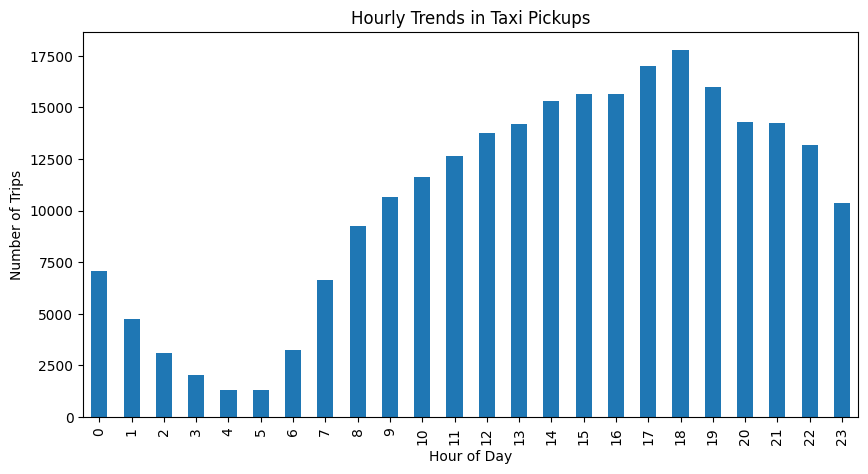

pickup_hour
0      7070
1      4744
2      3093
3      2021
4      1311
5      1297
6      3244
7      6643
8      9262
9     10635
10    11620
11    12662
12    13769
13    14211
14    15303
15    15658
16    15660
17    17007
18    17763
19    15963
20    14304
21    14229
22    13192
23    10356
dtype: int64


In [140]:
# Find and show the hourly trends in taxi pickups
# Extract hour from pickup datetime
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
# Counting number of trips per hour
hourly_trips = df.groupby('pickup_hour').size()
# plot
hourly_trips.plot(kind='bar', figsize=(10,5))
plt.title('Hourly Trends in Taxi Pickups')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.show()

# Display values
print(hourly_trips)

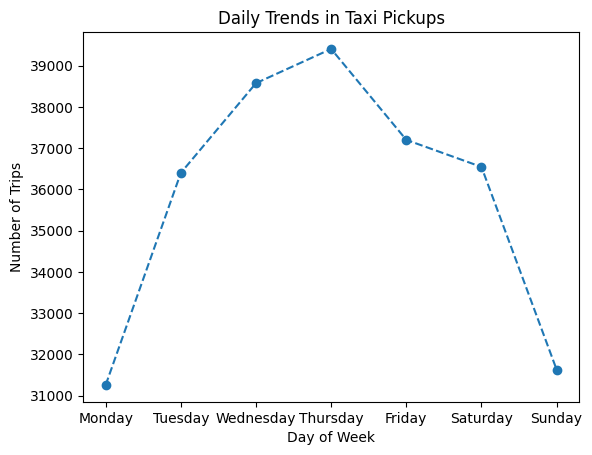

day_of_week
Monday       31260
Tuesday      36400
Wednesday    38575
Thursday     39405
Friday       37200
Saturday     36545
Sunday       31632
dtype: int64


In [141]:
# Find and show the daily trends in taxi pickups (days of the week)
df['day_of_week'] = df['tpep_pickup_datetime'].dt.day_name()
# Count trips per day
daily_trips = df.groupby('day_of_week').size()
# Arrange days in correct order
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily_trips = daily_trips.reindex(order)
# plot
daily_trips.plot(kind='line', marker='o', linestyle='--')
plt.title('Daily Trends in Taxi Pickups')
plt.xlabel('Day of Week')
plt.ylabel('Number of Trips')
plt.show()
print(daily_trips)

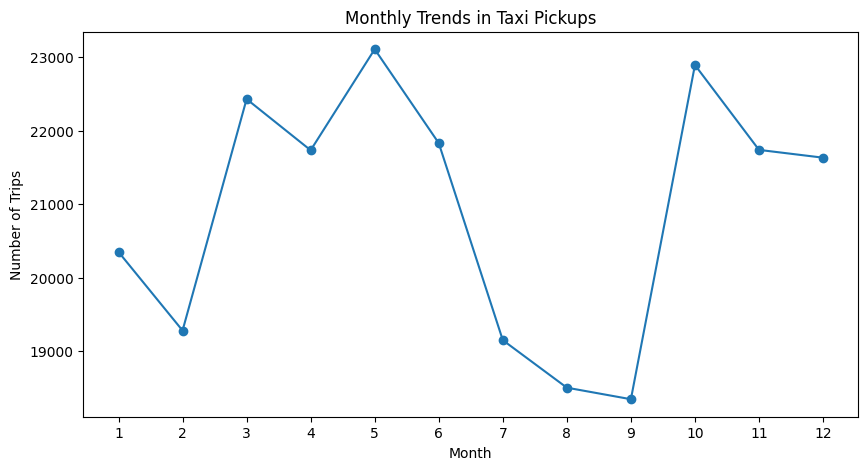

pickup_month
1     20352
2     19283
3     22431
4     21735
5     23109
6     21832
7     19152
8     18506
9     18349
10    22894
11    21740
12    21634
dtype: int64


In [142]:
# Show the monthly trends in pickups
# Extract month
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month
# Count trips per month
monthly_trips = df.groupby('pickup_month').size()
# Plot
monthly_trips.plot(kind='line', marker='o', figsize=(10,5))
plt.title('Monthly Trends in Taxi Pickups')
plt.xlabel('Month')
plt.ylabel('Number of Trips')
plt.xticks(range(1,13))
plt.show()
print(monthly_trips)


##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [143]:
# Analyse the above parameters

cols = ['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']

for col in cols:
    print(col)
    print("Zero values:", (df[col] == 0).sum())
    print("Negative values:", (df[col] < 0).sum())
    print("------")

fare_amount
Zero values: 69
Negative values: 0
------
tip_amount
Zero values: 54821
Negative values: 0
------
total_amount
Zero values: 28
Negative values: 0
------
trip_distance
Zero values: 2910
Negative values: 0
------


#Analysis

The dataset does not contain negative values after cleaning, but zero values are present in some financial columns. Zero values in fare_amount and total_amount are generally invalid and can affect the analysis, so it is beneficial to exclude them. However, zero values in tip_amount are valid as they indicate no tip given and should be retained. Similarly, zero values in trip_distance may be valid when the pickup and drop-off locations are the same, so such cases should not be blindly removed. Therefore, it is beneficial to create a filtered DataFrame that removes invalid zero values while retaining meaningful ones.

Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

Yes,it is beneficial to  create a copy of the dataFrame excluding the zeros for certain financial columns like fare amount,total amount,trip distance,as these 0's are likely to be invalid and can change analysis.However,0's in tip_amount are valid-No tip  and should retain it.Therefore,a filtered dataframe should be created by removing invalid 0's and keep only meaningful ones.

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

Zero values in fare_amount and total_amount are not valid for completed taxi trips, so these records should be removed. However, a trip_distance of zero does not always mean the row is incorrect, because the pickup and drop-off locations may be within the same zone. Therefore, zero-distance trips should not be removed automatically. Instead, records where trip_distance is zero while fare_amount is greater than zero should be checked separately, as these may indicate inconsistent fare data

trip_distance = 0  
BUT fare_amount > 0

In [144]:
# Create a df with non zero entries for the selected parameters.
# remove 0 fare,0 total,keep non zero distance or valid 0 distance
df_filter = df[
    (df['fare_amount'] > 0) &
    (df['total_amount'] > 0) &
    (
        (df['trip_distance'] > 0) |
        (df['pulocationid'] == df['dolocationid'])
    )
].copy()

df_filter.head()

,vendorid,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,ratecodeid,store_and_fwd_flag,pulocationid,dolocationid,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_hour,day_of_week,pickup_month
0,2,2023-05-01 00:08:25,2023-05-01 00:26:24,1.0,8.02,1.0,N,138,255,1,...,0.5,8.26,0.0,1.0,51.31,0.0,1.75,0,Monday,5
1,1,2023-05-01 00:28:28,2023-05-01 00:36:54,1.0,2.10,1.0,N,114,48,1,...,0.5,3.30,0.0,1.0,19.70,2.5,0.00,0,Monday,5
2,2,2023-05-01 00:12:17,2023-05-01 00:35:43,1.0,10.91,1.0,N,264,264,1,...,0.5,9.00,0.0,1.0,59.00,2.5,0.00,0,Monday,5
3,2,2023-05-01 00:12:04,2023-05-01 00:12:08,1.0,0.17,1.0,N,264,264,2,...,0.5,0.00,0.0,1.0,5.50,0.0,0.00,0,Monday,5
4,2,2023-05-01 00:30:00,2023-05-01 00:47:18,1.0,10.36,1.0,N,138,79,1,...,0.5,10.37,0.0,1.0,62.22,2.5,1.75,0,Monday,5


**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

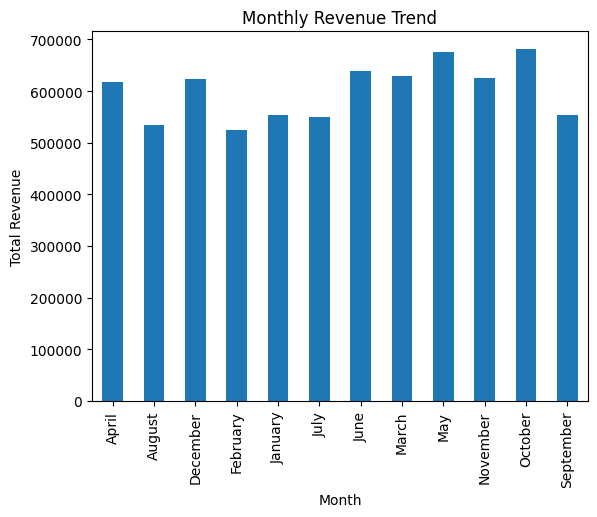

pickup_month
April        618243.30
August       535219.29
December     623631.87
February     525560.57
January      554494.25
July         549224.94
June         638750.81
March        629945.98
May          675004.82
November     625889.18
October      681575.53
September    553278.97
Name: total_amount, dtype: float64


In [145]:
# Group data by month and analyse monthly revenue

# Extract
df_filter['pickup_month'] = df_filter['tpep_pickup_datetime'].dt.month_name()

# Group by month and sum revenue
monthly_revenue = df_filter.groupby('pickup_month')['total_amount'].sum()

# Plot
monthly_revenue.plot(kind='bar')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.show()
print(monthly_revenue)

**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

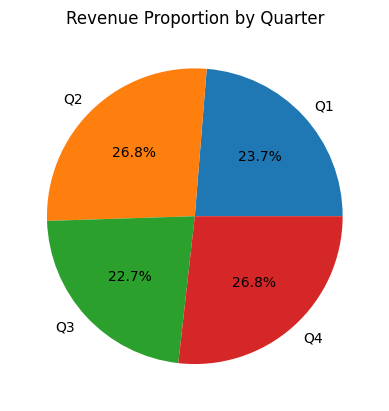

In [146]:
# Calculate proportion of each quarter
# Extract quarter
df_filter['quarter'] = df_filter['tpep_pickup_datetime'].dt.quarter

# Calculate revenue per quarter
quarter_revenue = df_filter.groupby('quarter')['total_amount'].sum()

# Convert to proportion
quarter_proportion = quarter_revenue / quarter_revenue.sum()

# Plot
import matplotlib.pyplot as plt

quarter_proportion.plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['Q1','Q2','Q3','Q4']
)

plt.title('Revenue Proportion by Quarter')
plt.ylabel('')
plt.show()



**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

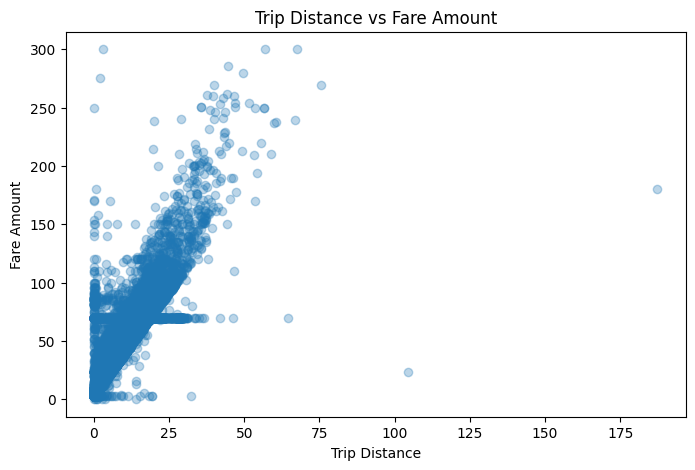

Correlation: 0.9456496071424951


In [147]:
# Show how trip fare is affected by distance
#Filter data (remove distance = 0)
df_corre = df_filter[df_filter['trip_distance'] > 0]
# plot-Scatter plot
plt.figure(figsize=(8,5))
plt.scatter(df_corre['trip_distance'], df_corre['fare_amount'], alpha=0.3)

plt.title('Trip Distance vs Fare Amount')
plt.xlabel('Trip Distance')
plt.ylabel('Fare Amount')
plt.show()
# Correlation
correlation = df_corre['trip_distance'].corr(df_corre['fare_amount'])
print("Correlation:", correlation)

**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

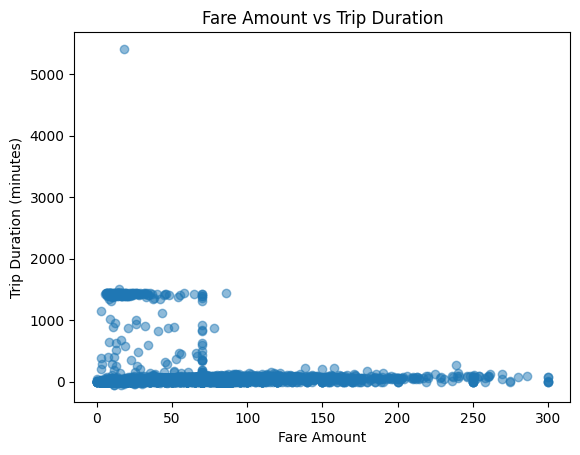

Correlation (fare vs duration): 0.2621248550548915


In [148]:
# Show relationship between fare and trip duration
# Create a copy
df_filter = df_filter.copy()
#calculate duration in minutes
df_filter['trip_duration'] = (
    df_filter['tpep_dropoff_datetime'] - df_filter['tpep_pickup_datetime']
).dt.total_seconds() / 60
# scatter plot
plt.scatter(df_filter['fare_amount'], df_filter['trip_duration'], alpha=0.5)
plt.title('Fare Amount vs Trip Duration')
plt.xlabel('Fare Amount')
plt.ylabel('Trip Duration (minutes)')
plt.show()

corr1 = df_filter['trip_duration'].corr(df_filter['fare_amount'])
print("Correlation (fare vs duration):", corr1)


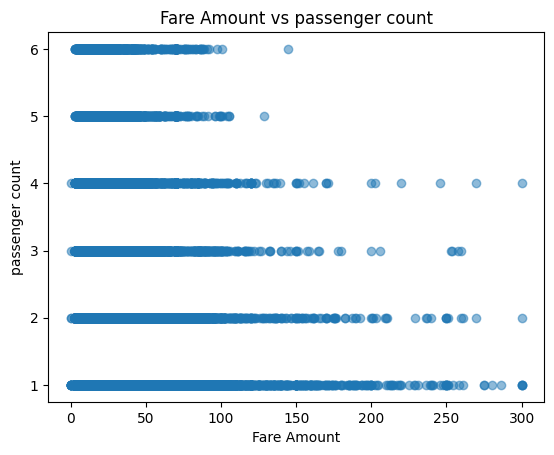

Correlation (fare vs passenger_count): 0.04686206709598218


In [149]:
# Show relationship between fare and number of passengers

plt.scatter(df_filter['fare_amount'], df_filter['passenger_count'], alpha=0.5)
plt.title('Fare Amount vs passenger count')
plt.xlabel('Fare Amount')
plt.ylabel('passenger count')
plt.show()

corr1 = df_filter['passenger_count'].corr(df_filter['fare_amount'])
print("Correlation (fare vs passenger_count):", corr1)


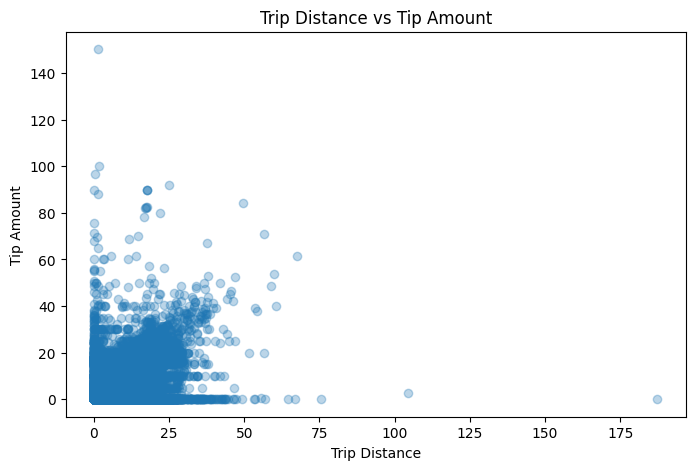

Correlation (tip vs distance): 0.5903750241716297


In [150]:
# Show relationship between tip and trip distance

plt.figure(figsize=(8,5))
plt.scatter(df_filter['trip_distance'], df_filter['tip_amount'], alpha=0.3)

plt.title('Trip Distance vs Tip Amount')
plt.xlabel('Trip Distance')
plt.ylabel('Tip Amount')
plt.show()

corr3 = df_filter['trip_distance'].corr(df_filter['tip_amount'])
print("Correlation (tip vs distance):", corr3)

**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

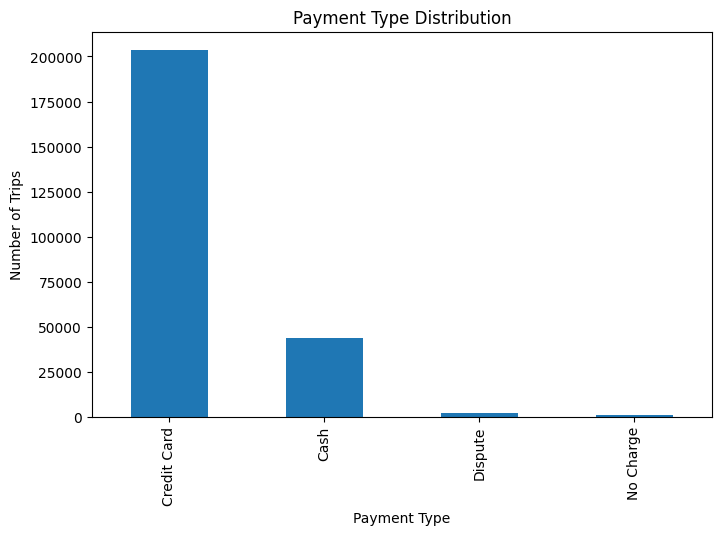

In [151]:
# Analyse the distribution of different payment types (payment_type).
# Counting values
paymt_counts = df_filter['payment_type'].value_counts()
paymt_counts
# Map
mapping = {
    1: 'Credit Card',
    2: 'Cash',
    3: 'No Charge',
    4: 'Dispute'
}
# Create label column safely
df_filter = df_filter.copy()
df_filter['payment_label'] = df_filter['payment_type'].map(mapping)

# Plot
df_filter['payment_label'].value_counts().plot(kind='bar', figsize=(8,5))

plt.title('Payment Type Distribution')
plt.xlabel('Payment Type')
plt.ylabel('Number of Trips')
plt.show()

- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

In [152]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [153]:
zip_path = "/content/drive/MyDrive/Datasets and Dictionary-NYC.zip"

In [154]:
import os

zip_path = '/content/drive/MyDrive/Datasets and Dictionary-NYC.zip'
print(os.path.exists(zip_path))

True


In [155]:
zip_path = r'/content/drive/MyDrive/Datasets and Dictionary-NYC.zip'

In [156]:
import zipfile

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/nyc_data')

In [157]:
os.listdir('/content/nyc_data')

['Datasets and Dictionary']

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [158]:
!pip install geopandas

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [159]:
# Try loading file
import geopandas as gpd
folder = '/content/nyc_data/Datasets and Dictionary/taxi_zones'

file_path = os.path.join(folder, 'taxi_zones.shp')

tz = gpd.read_file(file_path)

tz.info()
print(df.shape[0])
tz.head()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
251017


,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


<Axes: >

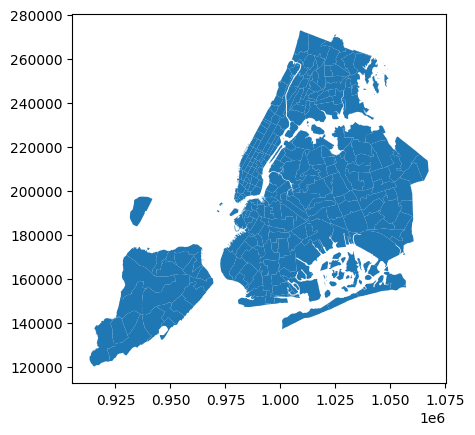

In [160]:
print(tz.info())
tz.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [161]:
# Merge zones and trip records using locationID and PULocationID


trip_zones = df_filter.merge(
    tz,
    left_on='pulocationid',
    right_on='LocationID',
    how='left'
)

trip_zones.head()

,vendorid,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,ratecodeid,store_and_fwd_flag,pulocationid,dolocationid,payment_type,...,quarter,trip_duration,payment_label,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,2,2023-05-01 00:08:25,2023-05-01 00:26:24,1.0,8.02,1.0,N,138,255,1,...,2,17.983333,Credit Card,138.0,0.107467,0.000537,LaGuardia Airport,138.0,Queens,"MULTIPOLYGON (((1019904.219 225677.983, 102031..."
1,1,2023-05-01 00:28:28,2023-05-01 00:36:54,1.0,2.10,1.0,N,114,48,1,...,2,8.433333,Credit Card,114.0,0.031727,0.000047,Greenwich Village South,114.0,Manhattan,"POLYGON ((986306.712 203122.786, 986300.242 20..."
2,2,2023-05-01 00:12:17,2023-05-01 00:35:43,1.0,10.91,1.0,N,264,264,1,...,2,23.433333,Credit Card,NaN,NaN,NaN,NaN,NaN,NaN,None
3,2,2023-05-01 00:12:04,2023-05-01 00:12:08,1.0,0.17,1.0,N,264,264,2,...,2,0.066667,Cash,NaN,NaN,NaN,NaN,NaN,NaN,None
4,2,2023-05-01 00:30:00,2023-05-01 00:47:18,1.0,10.36,1.0,N,138,79,1,...,2,17.300000,Credit Card,138.0,0.107467,0.000537,LaGuardia Airport,138.0,Queens,"MULTIPOLYGON (((1019904.219 225677.983, 102031..."


**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [162]:
# Group data by location and calculate the number of trips

trips_location = trip_zones.groupby(['LocationID','zone']).size().reset_index(name='trip_count')

trips_location.head()

,LocationID,zone,trip_count
0,1.0,Newark Airport,34
1,3.0,Allerton/Pelham Gardens,1
2,4.0,Alphabet City,235
3,6.0,Arrochar/Fort Wadsworth,3
4,7.0,Astoria,100


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [163]:
# Merge trip counts back to the zones GeoDataFrame
zones_with_trips = tz.merge(
    trips_location,
    on='LocationID',
    how='left'
)
# Clean duplicate zone colums zone_x,zone_y
zones_with_trips = zones_with_trips.drop(columns=['zone_y'])
zones_with_trips = zones_with_trips.rename(columns={'zone_x': 'zone'})
zones_with_trips['trip_count'] = zones_with_trips['trip_count'].fillna(0)
zones_with_trips.head()


,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,trip_count
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",34.0
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",0.0
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",1.0
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",235.0
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",0.0


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

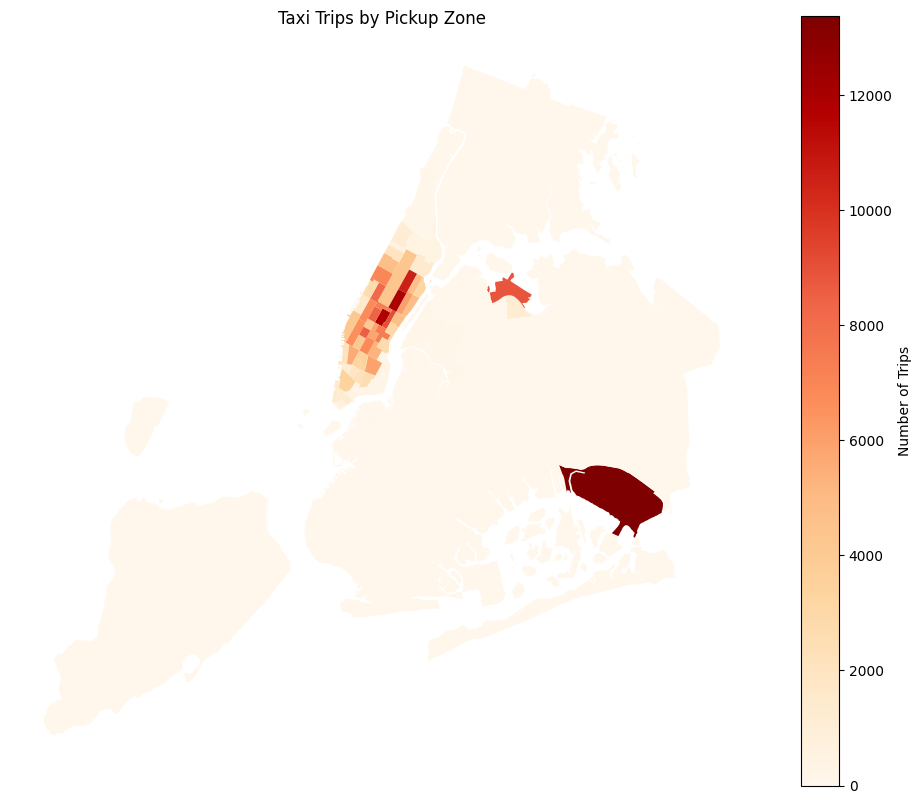

In [164]:
# Define figure and axis
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
# Plot the map and display it
zones_with_trips.plot(
    column='trip_count',
    ax=ax,
    cmap='OrRd',
    legend=True,
    legend_kwds={'label': 'Number of Trips'}
)

ax.set_title('Taxi Trips by Pickup Zone')
ax.axis('off')

plt.show()



In [165]:
# can you try displaying the zones DF sorted by the number of trips?
zones_with_trips.sort_values(by='trip_count', ascending=False).head(10)

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,trip_count
131,132,0.245479,0.002038,JFK Airport,132,Queens,"MULTIPOLYGON (((1032791.001 181085.006, 103283...",13386.0
236,237,0.042213,0.000096,Upper East Side South,237,Manhattan,"POLYGON ((993633.442 216961.016, 993507.232 21...",11890.0
160,161,0.035804,0.000072,Midtown Center,161,Manhattan,"POLYGON ((991081.026 214453.698, 990952.644 21...",11804.0
235,236,0.044252,0.000103,Upper East Side North,236,Manhattan,"POLYGON ((995940.048 221122.92, 995812.322 220...",10583.0
161,162,0.035270,0.000048,Midtown East,162,Manhattan,"POLYGON ((992224.354 214415.293, 992096.999 21...",9104.0
137,138,0.107467,0.000537,LaGuardia Airport,138,Queens,"MULTIPOLYGON (((1019904.219 225677.983, 102031...",8866.0
185,186,0.024696,0.000037,Penn Station/Madison Sq West,186,Manhattan,"POLYGON ((986752.603 210853.699, 986627.863 21...",8551.0
229,230,0.031028,0.000056,Times Sq/Theatre District,230,Manhattan,"POLYGON ((988786.877 214532.094, 988650.277 21...",8420.0
141,142,0.038176,0.000076,Lincoln Square East,142,Manhattan,"POLYGON ((989380.305 218980.247, 989359.803 21...",8173.0
169,170,0.045769,0.000074,Murray Hill,170,Manhattan,"POLYGON ((991999.299 210994.739, 991972.635 21...",7422.0


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


**General Analysis**
##Temporal
Taxi demand shows clear variation across time.
Busiest hours are typically during morning and evening peak times, reflecting commuter travel.
Weekdays generally have higher trip volumes compared to weekends due to work-related travel.
Monthly trends indicate fluctuations in demand, suggesting possible seasonal patterns.

##Revenue Trends
Revenue follows a similar pattern to trip demand, increasing during peak travel periods.
Months with higher trip counts generate higher total revenue.
This indicates a strong relationship between trip frequency and overall earnings.

#Quarterly Revenue Trends
Revenue distribution across quarters shows variation in contribution to total annual revenue.
Certain quarters contribute more significantly, likely due to increased travel activity during those periods.
This highlights seasonal demand differences in taxi usage.
# Fare Relationships
A strong positive relationship exists between trip distance and fare amount, indicating that longer trips result in higher fares.
Fare amount also increases with trip duration, as longer trips typically cost more.
Passenger count has little to no impact on fare, suggesting pricing is primarily based on distance and time rather than number of passengers.
#Tip Trends
There is a positive but weaker relationship between trip distance and tip amount.
Longer trips tend to receive slightly higher tips, although tipping behavior varies significantly among passengers.
# Geographical Insights
Certain zones have significantly higher trip counts, indicating high-demand areas.
These zones are typically located in central and densely populated regions (e.g., major commercial or transport hubs).
Less active zones show comparatively low taxi usage.

Overall, the analysis reveals that taxi demand and revenue are highly influenced by time, location, and trip characteristics. Distance and duration are the primary drivers of fare, while geographical hotspots highlight areas of concentrated taxi activity.




#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [166]:
# Find routes which have the slowest speeds at different times of the day
# trip_duration in minutes
df_filter = df_filter[df_filter['trip_duration'] > 0]

routes = df_filter.groupby(
    ['pulocationid', 'dolocationid', 'pickup_hour']
).agg(
    avg_distance=('trip_distance', 'mean'),
    avg_duration_min=('trip_duration', 'mean')
).reset_index()

# convert to mph
routes['speed_mph'] = routes['avg_distance'] / (routes['avg_duration_min'] / 60)

slow_routes = routes.sort_values(by='speed_mph').head(10)
slow_routes

,pulocationid,dolocationid,pickup_hour,avg_distance,avg_duration_min,speed_mph
0,1,1,5,0.0,0.241667,0.0
21566,137,137,2,0.0,2.083333,0.0
21567,137,137,3,0.0,0.100000,0.0
21568,137,137,4,0.0,0.491667,0.0
21577,137,137,14,0.0,0.500000,0.0
56505,261,261,21,0.0,0.166667,0.0
56504,261,261,19,0.0,0.283333,0.0
56502,261,261,17,0.0,0.100000,0.0
55774,255,255,4,0.0,0.383333,0.0
56496,261,261,8,0.0,0.183333,0.0


How does identifying high-traffic, high-demand routes help us?

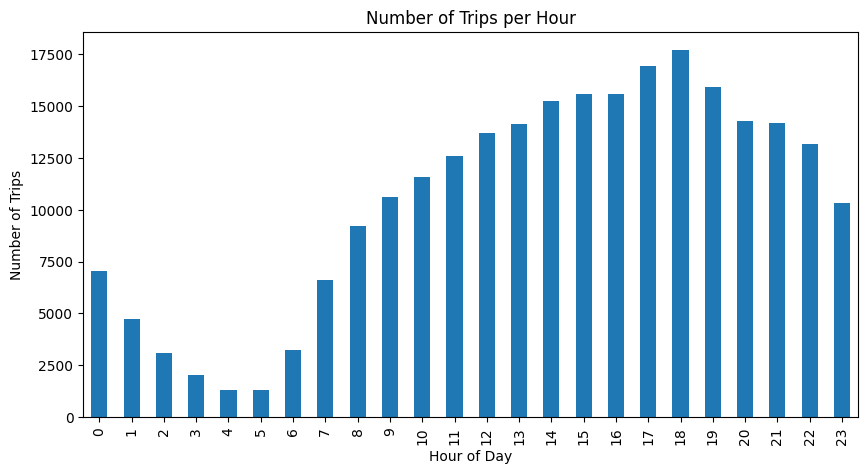

Busiest Hour: 18
Number of Trips: 17692


In [167]:
# Visualise the number of trips per hour and find the busiest hour

# Group-trips by hour
hourly_trips = df_filter.groupby('pickup_hour').size()

# Plot
hourly_trips.plot(kind='bar', figsize=(10,5))
plt.title('Number of Trips per Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.show()

# Find busiest hour
busiest_hour = hourly_trips.idxmax()
max_trips = hourly_trips.max()

print("Busiest Hour:", busiest_hour)
print("Number of Trips:", max_trips)




Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [168]:
# Scale up the number of trips

# Fill in the value of your sampling fraction and use that to scale up the numbers
top5 = hourly_trips.sort_values(ascending=False).head(5)
top5

sampling_fraction = 0.007

scaling_factor = 1 / sampling_fraction

actual_top5 = top5 * scaling_factor
actual_top5 = actual_top5.reset_index()
actual_top5.columns = ['Hour', 'Estimated Trips']
actual_top5

,Hour,Estimated Trips
0,18,2.527429e+06
1,17,2.420286e+06
2,19,2.273143e+06
3,16,2.227286e+06
4,15,2.225429e+06


**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

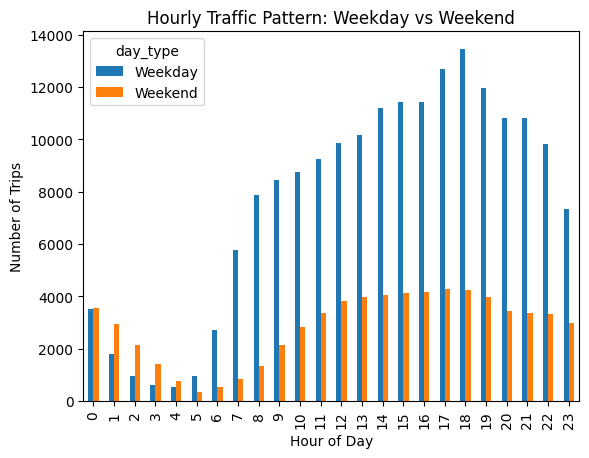

In [169]:
# Compare traffic trends for the week days and weekends

df_filter['day_of_week'] = df_filter['tpep_pickup_datetime'].dt.dayofweek
df_filter['day_type'] = df_filter['day_of_week'].apply(
    lambda x: 'Weekend' if x >= 5 else 'Weekday'
)

traffic = df_filter.pivot_table(
    index='pickup_hour',
    columns='day_type',
    aggfunc='size',
    fill_value=0
)

traffic.plot(kind='bar')
plt.title('Hourly Traffic Pattern: Weekday vs Weekend')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.show()

What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

Weekday traffic peaks during morning and evening commute hours, while weekend traffic is more evenly distributed with moderate activity during late mornings and evenings

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

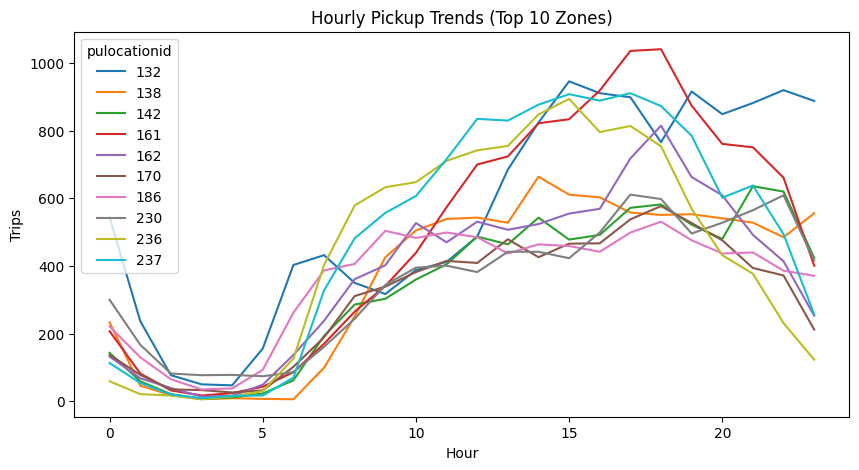

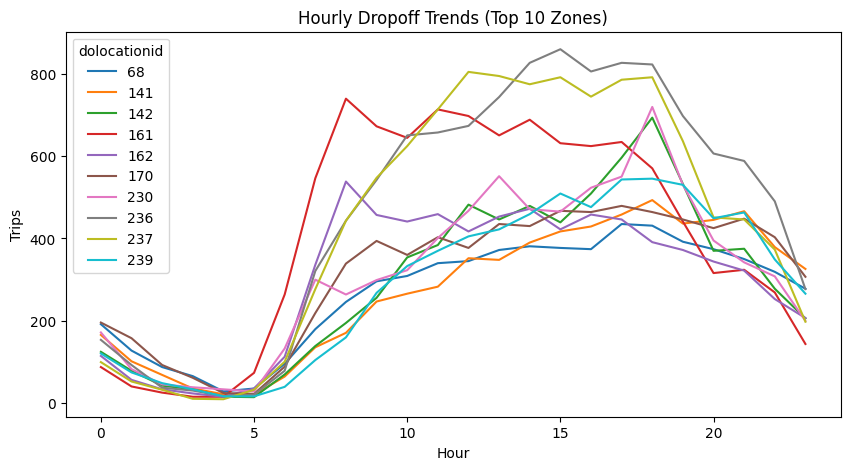

In [170]:
# Find top 10 pickup and dropoff zones
top_pickup = df_filter.groupby('pulocationid').size().sort_values(ascending=False).head(10)
top_pickup
top_dropoff = df_filter.groupby('dolocationid').size().sort_values(ascending=False).head(10)
top_dropoff

pickup_trend = df_filter[df_filter['pulocationid'].isin(top_pickup.index)].pivot_table(
    index='pickup_hour',
    columns='pulocationid',
    aggfunc='size',
    fill_value=0
)

pickup_trend.plot(figsize=(10,5))
plt.title('Hourly Pickup Trends (Top 10 Zones)')
plt.xlabel('Hour')
plt.ylabel('Trips')
plt.show()


dropoff_trend = df_filter[df_filter['dolocationid'].isin(top_dropoff.index)].pivot_table(
    index='pickup_hour',
    columns='dolocationid',
    aggfunc='size',
    fill_value=0)

dropoff_trend.plot(figsize=(10,5))
plt.title('Hourly Dropoff Trends (Top 10 Zones)')
plt.xlabel('Hour')
plt.ylabel('Trips')
plt.show()

**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [171]:
# Find the top 10 and bottom 10 pickup/dropoff ratios

# Pickup counts
pickup_counts = df_filter.groupby('pulocationid').size()

# Dropoff counts
dropoff_counts = df_filter.groupby('dolocationid').size()

# Combine properly using index
ratio_df = pd.concat(
    [pickup_counts, dropoff_counts],
    axis=1
).fillna(0)

ratio_df.columns = ['pickup', 'dropoff']

# Avoid division by zero
ratio_df = ratio_df[ratio_df['dropoff'] > 0]

# Calculate ratio
ratio_df['ratio'] = ratio_df['pickup'] / ratio_df['dropoff']

# Top 10 highest ratios
top10 = ratio_df.sort_values(by='ratio', ascending=False).head(10)

# Bottom 10 lowest ratios
bottom10 = ratio_df.sort_values(by='ratio').head(10)

top10, bottom10


(      pickup  dropoff     ratio
 70    1167.0      136  8.580882
 132  13386.0     2824  4.740085
 138   8866.0     3039  2.917407
 186   8550.0     5683  1.504487
 43    4304.0     3067  1.403326
 249   5629.0     4117  1.367258
 114   3283.0     2427  1.352699
 162   9103.0     7183  1.267298
 161  11804.0     9827  1.201180
 100   4122.0     3454  1.193399,
      pickup  dropoff  ratio
 259     0.0       25    0.0
 98      0.0       39    0.0
 91      0.0       49    0.0
 81      0.0       14    0.0
 78      0.0       16    0.0
 77      0.0       14    0.0
 73      0.0       15    0.0
 72      0.0       44    0.0
 71      0.0       41    0.0
 63      0.0       50    0.0)

**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [172]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones

# Filter night hours: 11 PM to 5 AM

night_data = df_filter[
    (df_filter['pickup_hour'] >= 23) | (df_filter['pickup_hour'] <= 5)
]

# Top 10 pickup zones during night
night_pickups = (
    night_data.groupby('pulocationid')
    .size()
    .sort_values(ascending=False)
    .head(10)
)
print("Top 10 Night Pickup Zones")
display(night_pickups)

# Top 10 dropoff zones during night
night_dropoffs = (
    night_data.groupby('dolocationid')
    .size()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 Night Dropoff Zones")
display(night_dropoffs)

Top 10 Night Pickup Zones


,0
pulocationid,
79,2154
132,1999
249,1751
48,1426
148,1353
230,1194
114,1164
186,953
138,875


Top 10 Night Dropoff Zones


,0
dolocationid,
79,1157
48,967
170,864
107,819
68,817
141,742
263,713
249,657
236,632


Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

In [173]:
# Filter for night hours (11 PM to 5 AM)
#pickup_hour
df_filter['pickup_hour'] = df_filter['tpep_pickup_datetime'].dt.hour
#Night data (11 PM to 5 AM)
night_data = df_filter[
    (df_filter['pickup_hour'] >= 23) | (df_filter['pickup_hour'] <= 5)
]
# Day data
day_data = df_filter[
    (df_filter['pickup_hour'] > 5) & (df_filter['pickup_hour'] < 23)
]
# Calculate revenue
total_revenue = df_filter['total_amount'].sum()
night_revenue = night_data['total_amount'].sum()
day_revenue = day_data['total_amount'].sum()
# Revenue share
night_share = night_revenue / total_revenue
day_share = day_revenue / total_revenue
print("Night Revenue Share: {:.2f}%".format(night_share * 100))
print("Day Revenue Share: {:.2f}%".format(day_share * 100))

Night Revenue Share: 12.20%
Day Revenue Share: 87.80%


##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

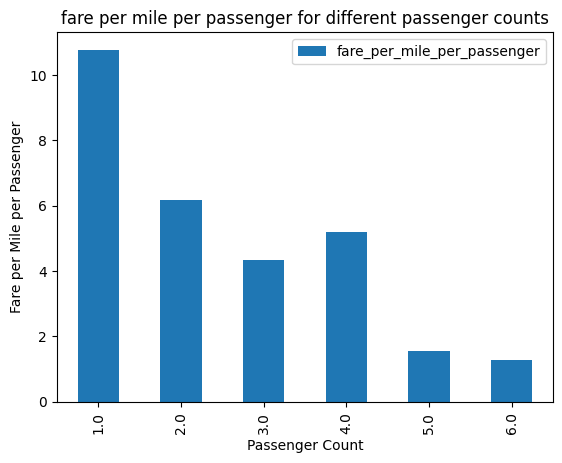

   passenger_count  fare_per_mile_per_passenger
0              1.0                    10.767832
1              2.0                     6.183695
2              3.0                     4.332405
3              4.0                     5.183126
4              5.0                     1.565300
5              6.0                     1.285477


In [174]:
# Analyse the fare per mile per passenger for different passenger counts
# Create copy
df_ps = df_filter.copy()

# Remove invalid rows
df_ps = df_ps[
    (df_ps['trip_distance'] > 0) &
    (df_ps['passenger_count'] > 0)
]

# Calculate fare per mile per passenger
df_ps['fare_per_mile_per_passenger'] = (
    df_ps['fare_amount'] /
    (df_ps['trip_distance'] * df_ps['passenger_count'])
)

# Group by passenger count
fare_analysis = df_ps.groupby('passenger_count')[
    'fare_per_mile_per_passenger'
].mean().reset_index()


fare_analysis.plot(
    kind='bar',
    x='passenger_count',
    y='fare_per_mile_per_passenger',

)
plt.title('fare per mile per passenger for different passenger counts')
plt.xlabel('Passenger Count')
plt.ylabel('Fare per Mile per Passenger')
plt.show()
print(fare_analysis)

**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

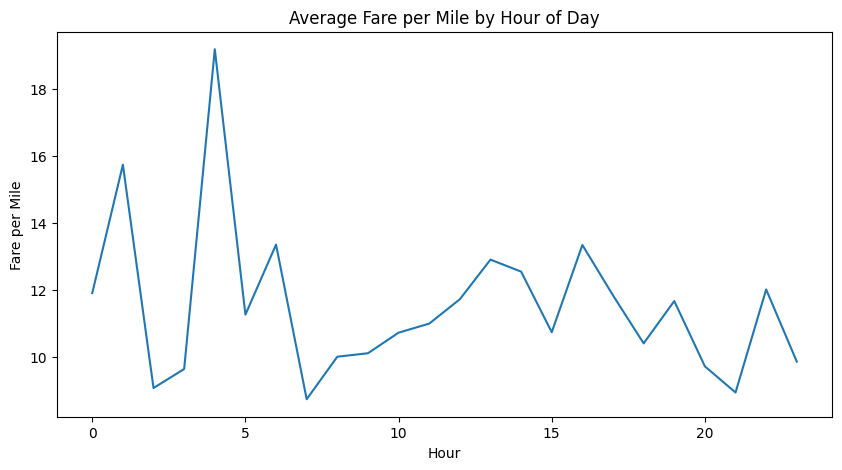

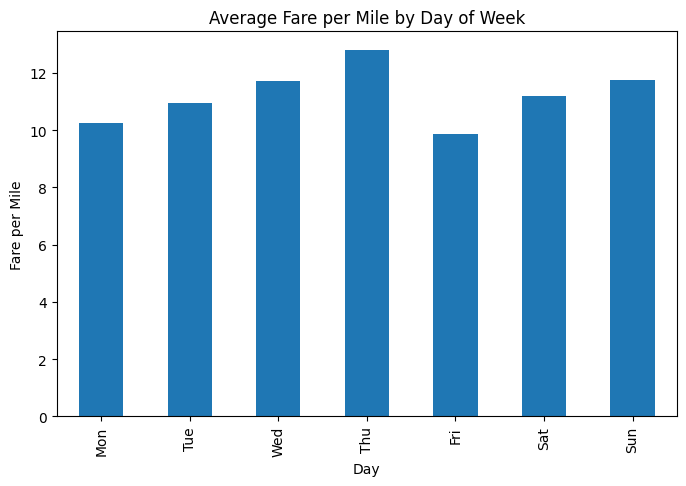

In [175]:
# Compare the average fare per mile for different days and for different times of the day
#fare_per_mile = fare_amount / trip_distance

df_fp = df_filter.copy()

# Remove invalid rows
df_fp = df_fp[df_fp['trip_distance'] > 0]

# Calculate fare per mile
df_fp['fare_per_mile'] = df_fp['fare_amount'] / df_fp['trip_distance']
#times of the day
hourly_fare = df_fp.groupby('pickup_hour')['fare_per_mile'].mean()

hourly_fare.plot(figsize=(10,5))
plt.title('Average Fare per Mile by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Fare per Mile')
plt.show()
# days of the week
# Extract day
df_fp['day_of_week'] = df_fp['tpep_pickup_datetime'].dt.dayofweek

# Map for readability
day_map = {
    0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu',
    4:'Fri', 5:'Sat', 6:'Sun'
}
df_fp['day_name'] = df_fp['day_of_week'].map(day_map)

daily_fare = df_fp.groupby('day_name')['fare_per_mile'].mean()

# Keep proper order
daily_fare = daily_fare.reindex(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])

daily_fare.plot(kind='bar', figsize=(8,5))
plt.title('Average Fare per Mile by Day of Week')
plt.xlabel('Day')
plt.ylabel('Fare per Mile')
plt.show()


**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

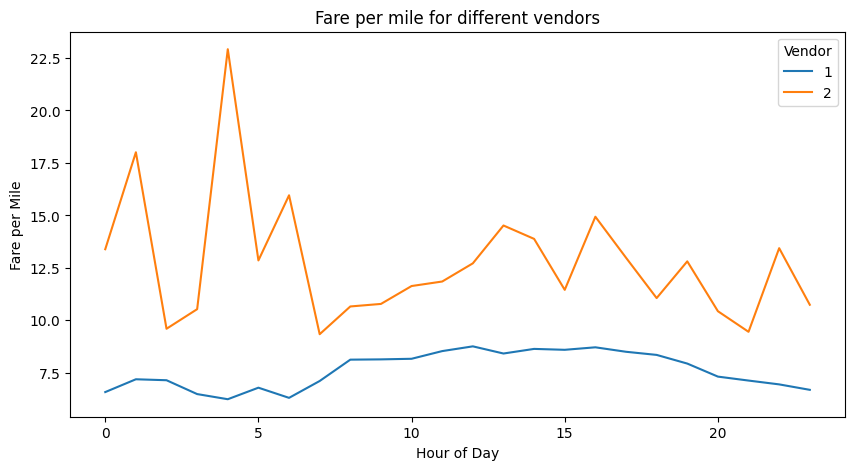

vendorid,1,2
pickup_hour,,
0,6.578368,13.387493
1,7.188603,18.009461
2,7.142913,9.596459
3,6.482969,10.530111
4,6.237769,22.920587
5,6.787444,12.853472
6,6.302904,15.958359
7,7.106512,9.336904
8,8.123685,10.659111


In [176]:
# Compare fare per mile for different vendors

# Create copy
df_fp = df_filter.copy()

# Remove invalid rows
df_fp = df_fp[df_fp['trip_distance'] > 0]

# Calculate fare per mile
df_fp['fare_per_mile'] = df_fp['fare_amount'] / df_fp['trip_distance']

# Extract hour
df_fp['pickup_hour'] = df_fp['tpep_pickup_datetime'].dt.hour

# Pivot table: vendor vs hour
vendor_hour_fare = df_fp.pivot_table(
    values='fare_per_mile',
    index='pickup_hour',
    columns='vendorid',
    aggfunc='mean'
)

vendor_hour_fare.plot(figsize=(10,5))

plt.title('Fare per mile for different vendors')
plt.xlabel('Hour of Day')
plt.ylabel('Fare per Mile')

plt.legend(title='Vendor')
plt.show()

vendor_hour_fare

**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


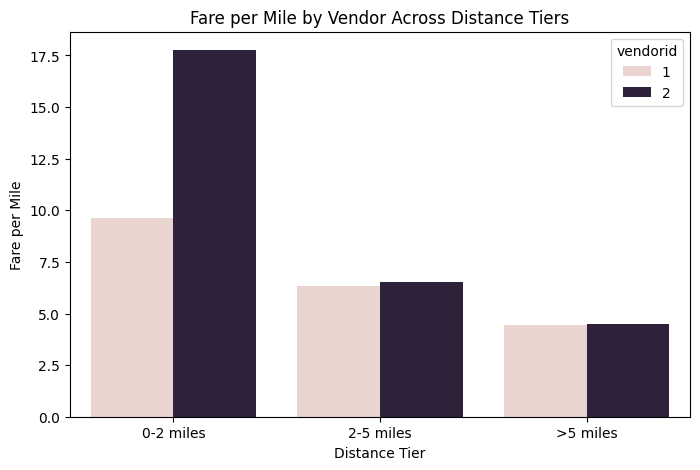

In [177]:
# Defining distance tiers

df_fp = df_filter.copy()

# Remove invalid rows
df_fp = df_fp[df_fp['trip_distance'] > 0]

# Calculate fare per mile
df_fp['fare_per_mile'] = df_fp['fare_amount'] / df_fp['trip_distance']

def distances_tier(d):
    if d <= 2:
        return '0-2 miles'
    elif d <= 5:
        return '2-5 miles'
    else:
        return '>5 miles'

df_fp['distances_tier'] = df_fp['trip_distance'].apply(distances_tier)

tier_analysis = df_fp.groupby(['distances_tier', 'vendorid']
)['fare_per_mile'].mean().reset_index()

tier_analysis

#plot
plt.figure(figsize=(8,5))

sns.barplot(
    data=tier_analysis,
    x='distances_tier',
    y='fare_per_mile',
    hue='vendorid'
)

plt.title('Fare per Mile by Vendor Across Distance Tiers')
plt.xlabel('Distance Tier')
plt.ylabel('Fare per Mile')

plt.show()

##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

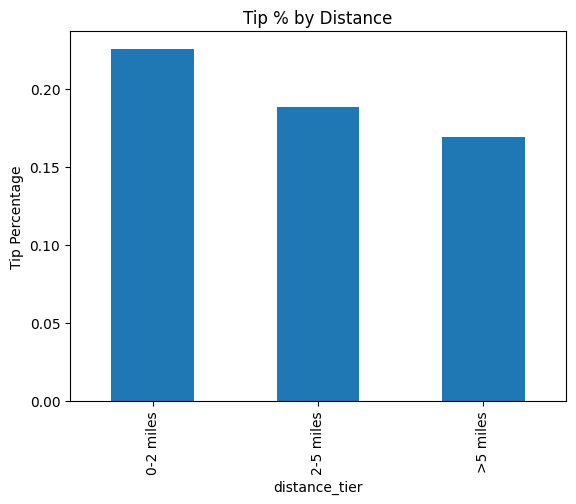

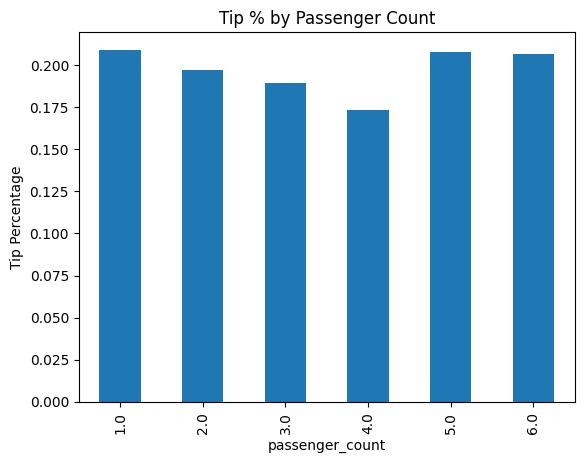

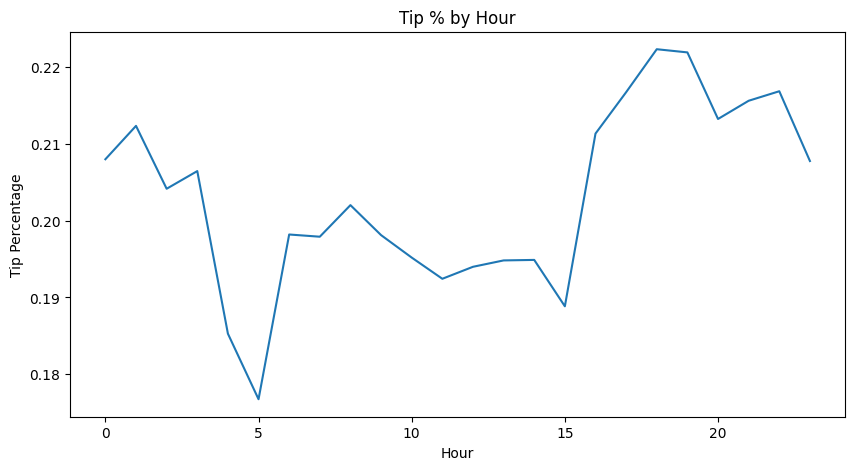

In [178]:
#  Analyze tip percentages based on distances, passenger counts and pickup times

df_tip = df_filter.copy()

# Remove invalid rows
df_tip = df_tip[df_tip['fare_amount'] > 0]

# Tip percentage
df_tip['tip_percentage'] = df_tip['tip_amount'] / df_tip['fare_amount']

# Distance-wise analysis
def dist_tier(d):
    if d <= 2:
        return '0-2 miles'
    elif d <= 5:
        return '2-5 miles'
    else:
        return '>5 miles'

df_tip['distance_tier'] = df_tip['trip_distance'].apply(dist_tier)

dist_tip = df_tip.groupby('distance_tier')['tip_percentage'].mean()
dist_tip.plot(kind='bar', title='Tip % by Distance')
plt.ylabel('Tip Percentage')
plt.show()

# Passenger count analysis
pass_tip = df_tip.groupby('passenger_count')['tip_percentage'].mean()
pass_tip.plot(kind='bar', title='Tip % by Passenger Count')
plt.ylabel('Tip Percentage')
plt.show()

#Time-based analysis
df_tip['pickup_hour'] = df_tip['tpep_pickup_datetime'].dt.hour

hour_tip = df_tip.groupby('pickup_hour')['tip_percentage'].mean()
hour_tip.plot(figsize=(10,5), title='Tip % by Hour')
plt.ylabel('Tip Percentage')
plt.xlabel('Hour')
plt.show()

Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [179]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%
# Low tips → tip % < 10%  #  High tips → tip % > 25%


**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

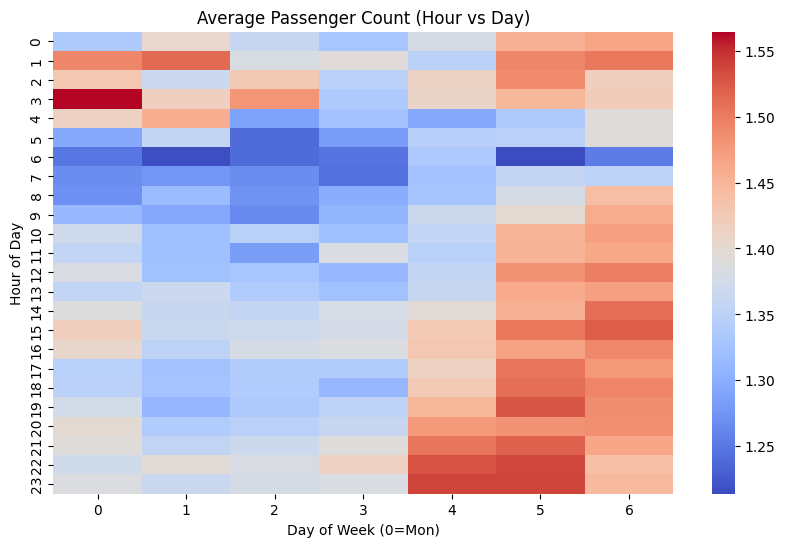

In [180]:
# See how passenger count varies across hours and  days

df_pc = df_filter.copy()

# Extract time
df_pc['pickup_hour'] = df_pc['tpep_pickup_datetime'].dt.hour
df_pc['day_of_week'] = df_pc['tpep_pickup_datetime'].dt.dayofweek

# Pivot table
passenger_pivot = df_pc.pivot_table(
    values='passenger_count',
    index='pickup_hour',
    columns='day_of_week',
    aggfunc='mean'
)

passenger_pivot

plt.figure(figsize=(10,6))
sns.heatmap(passenger_pivot, cmap='coolwarm')

plt.title('Average Passenger Count (Hour vs Day)')
plt.xlabel('Day of Week (0=Mon)')
plt.ylabel('Hour of Day')

plt.show()

**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

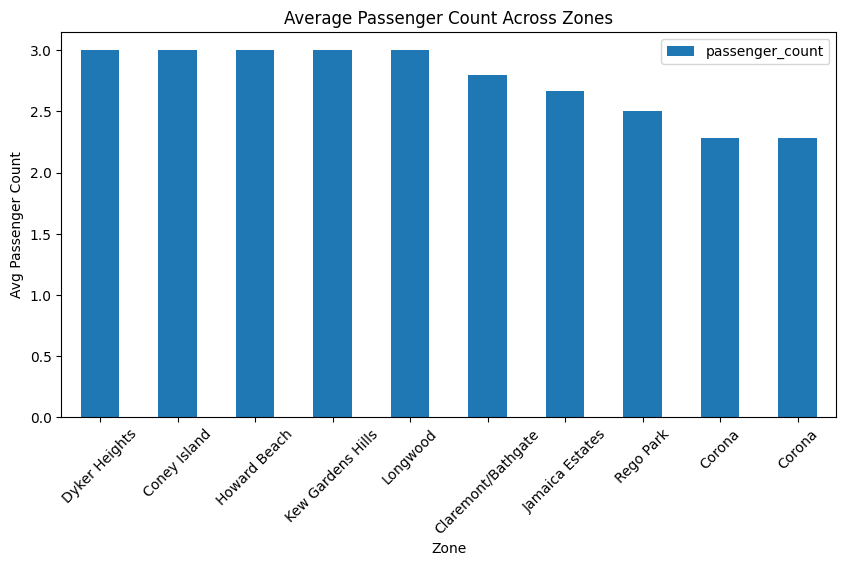

In [181]:
# How does passenger count vary across zones
#average passenger count per pickup zone
passenger_zone = df_filter.groupby('pulocationid')['passenger_count'].mean().reset_index()
#merge with zone names
passenger_zone = passenger_zone.merge(
    tz[['LocationID', 'zone']],
    left_on='pulocationid',
    right_on='LocationID',
    how='left'
)
# Sort to observe variation
passenger_zone = passenger_zone.sort_values(by='passenger_count', ascending=False)
# Display top zones
passenger_zone[['zone', 'passenger_count']].head(10)

#plot
top_zones = passenger_zone.head(10)
top_zones.plot(
    kind='bar',
    x='zone',
    y='passenger_count',
    figsize=(10,5)
)

plt.title('Average Passenger Count Across Zones')
plt.xlabel('Zone')
plt.ylabel('Avg Passenger Count')
plt.xticks(rotation=45)
plt.show()

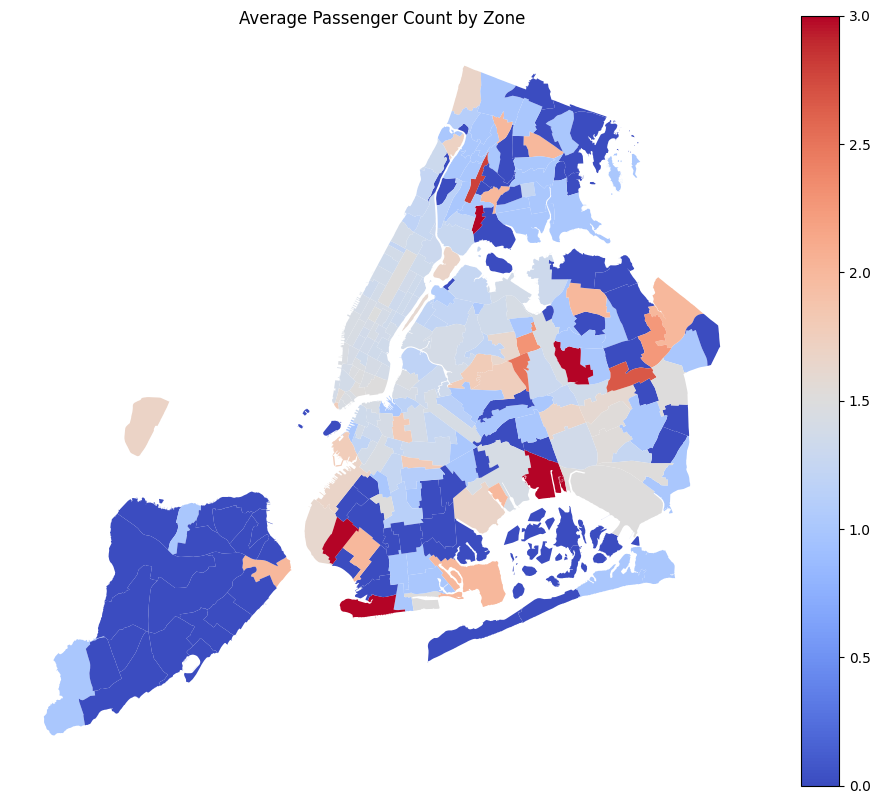

In [182]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.

#average passenger count per pickup zone

zone_passenger = df_filter.groupby('pulocationid')['passenger_count'].mean().reset_index()

# Merge with zones GeoDataFrame
zones_with_passenger = zones_with_trips.merge(
    zone_passenger,
    left_on='LocationID',
    right_on='pulocationid',
    how='left'
)
#Handle missing values
zones_with_passenger['passenger_count'] = zones_with_passenger['passenger_count'].fillna(0)

zones_with_passenger.head()

fig, ax = plt.subplots(1,1, figsize=(12,10))

zones_with_passenger.plot(
    column='passenger_count',
    cmap='coolwarm',
    legend=True,
    ax=ax
)

ax.set_title('Average Passenger Count by Zone')
ax.axis('off')

plt.show()



Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

Top Pickup Zones with Extra Charges


,pulocationid,charge_frequency,LocationID,zone
20,34,1.000000,34.0,Brooklyn Navy Yard
2,4,1.000000,4.0,Alphabet City
106,149,1.000000,149.0,Madison
153,210,1.000000,210.0,Sheepshead Bay
31,46,1.000000,46.0,City Island
36,51,1.000000,51.0,Co-Op City
7,12,1.000000,12.0,Battery Park
13,20,1.000000,20.0,Belmont
165,224,1.000000,224.0,Stuy Town/Peter Cooper Village
95,137,0.999281,137.0,Kips Bay


Top Dropoff Zones with Extra Charges


,dolocationid,charge_frequency,LocationID,zone
2,4,1.000000,4.0,Alphabet City
3,5,1.000000,5.0,Arden Heights
97,99,1.000000,99.0,Freshkills Park
105,111,1.000000,111.0,Green-Wood Cemetery
214,224,1.000000,224.0,Stuy Town/Peter Cooper Village
149,156,1.000000,156.0,Mariners Harbor
10,12,1.000000,12.0,Battery Park
58,59,1.000000,59.0,Crotona Park
224,234,0.999481,234.0,Union Sq
130,137,0.999347,137.0,Kips Bay


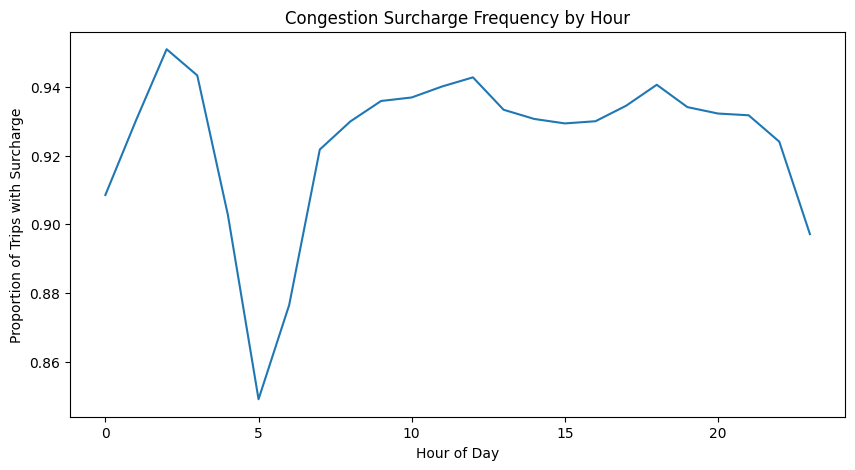

In [183]:
#Create a copy
df_extra = df_filter.copy()

# Extract pickup hour
df_extra['pickup_hour'] = df_extra['tpep_pickup_datetime'].dt.hour

# -------------------------------
# 1. Pickup zones with frequent extra charges
pickup_charge = df_extra.groupby('pulocationid')['congestion_surcharge'].apply(
    lambda x: (x > 0).mean()
).reset_index(name='charge_frequency')

pickup_charge = pickup_charge.merge(
    tz[['LocationID', 'zone']],
    left_on='pulocationid',
    right_on='LocationID',
    how='left'
)

top_pickup_charge = pickup_charge.sort_values(
    by='charge_frequency',
    ascending=False
).head(10)

print("Top Pickup Zones with Extra Charges")
display(top_pickup_charge)


# -------------------------------
# 2. Dropoff zones with frequent extra charges
dropoff_charge = df_extra.groupby('dolocationid')['congestion_surcharge'].apply(
    lambda x: (x > 0).mean()
).reset_index(name='charge_frequency')

dropoff_charge = dropoff_charge.merge(
    tz[['LocationID', 'zone']],
    left_on='dolocationid',
    right_on='LocationID',
    how='left'
)

top_dropoff_charge = dropoff_charge.sort_values(
    by='charge_frequency',
    ascending=False
).head(10)

print("Top Dropoff Zones with Extra Charges")
display(top_dropoff_charge)


# -------------------------------
# 3. Time when extra charges are applied more frequently
hour_charge = df_extra.groupby('pickup_hour')['congestion_surcharge'].apply(
    lambda x: (x > 0).mean()
)

plt.figure(figsize=(10,5))
hour_charge.plot()
plt.title('Congestion Surcharge Frequency by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Proportion of Trips with Surcharge')
plt.show()

In [184]:
# How often is each surcharge applied?

charges = [
    'extra',
    'mta_tax',
    'improvement_surcharge',
    'congestion_surcharge',
    'airport_fee'
]

total_trips = len(df_filter)

results = []

for col in charges:
    count = (df_filter[col] > 0).sum()
    percentage = (count / total_trips) * 100

    results.append({
        'charge_type': col,
        'applied_count': count,
        'percentage': percentage
    })

import pandas as pd
charge_df = pd.DataFrame(results)

charge_df

,charge_type,applied_count,percentage
0,extra,154549,61.816880
1,mta_tax,247856,99.138038
2,improvement_surcharge,250009,99.999200
3,congestion_surcharge,232553,93.017107
4,airport_fee,22316,8.926007


## **4** Conclusion
<font color = red>[15 marks]</font> <br>

The analysis of taxi trip data highlights that demand, pricing, and operational efficiency are strongly influenced by time, location, and trip characteristics. Demand is highest during weekday peak hours and weekend evenings, while certain zones consistently show higher activity due to commercial and social travel patterns.

Revenue and pricing trends indicate that fare structures vary with distance and demand, and additional charges are more common in high-traffic zones and peak periods. Passenger behavior also differs across zones, with solo travel dominating business areas and group travel more common in residential and leisure zones.

Overall, the findings show that taxi operations can be significantly improved by using data-driven strategies based on time and location patterns to better match supply with customer demand.

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>
The analysis of taxi trip data shows that demand, pricing, and operational efficiency are strongly influenced by time of day, day of the week, and location. These factors should be carefully considered to design an effective strategy for meeting customer demand and optimizing supply.

Taxi demand varies significantly across time. Weekday mornings and evenings show peak demand due to office commuting, while weekends and late evenings have higher demand driven by leisure and social activities. This indicates that cab availability should be adjusted based on hourly and weekly demand patterns.

Location plays a crucial role in demand distribution. Certain zones, especially commercial and central areas, consistently experience higher pickup and dropoff activity. These zones also show a higher frequency of congestion surcharges, indicating heavy traffic and high demand. In contrast, outer zones have lower demand and fewer additional charges. This highlights the need for zone-based cab allocation.

Revenue trends follow demand patterns, with higher earnings during peak hours and in busy zones. Pricing analysis shows that short trips have higher fare per mile, while longer trips are more cost-efficient. Additionally, fare per passenger decreases with higher passenger counts, supporting the promotion of shared rides.

Passenger behavior also varies across zones, with business areas showing more solo travel and residential or leisure areas showing group travel patterns. Tipping behavior depends on distance, time, and passenger count, with lower tips observed in short trips and late-night travel.

Surcharge analysis shows that some charges are applied consistently, while others depend on traffic conditions, time, and location, reinforcing the importance of demand-based pricing
#Recommendations
To optimize supply and meet customer demand effectively:

Align cab availability with demand patterns by increasing supply in high-demand zones during peak hours
Use dynamic pricing strategies based on time, location, and demand to maximize revenue
Implement smart routing to avoid congested and slow routes
Promote ride-sharing to improve efficiency and reduce cost per passenger
Continuously reposition taxis based on real-time demand and recent trip patterns
Adjust fleet distribution based on weekly and monthly demand trends
#Conclusion
Overall, an efficient taxi service strategy should integrate time-based demand, location-based patterns, passenger behavior, and pricing insights. By using a data-driven approach to dispatching, routing, and pricing, the service can improve utilization, reduce inefficiencies, increase revenue, and enhance customer satisfaction.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

Based on the analysis of demand patterns and operational inefficiencies, the following strategies can be implemented:

Taxi demand varies significantly across time and location, with peak demand observed during morning and evening hours on weekdays and late evenings on weekends. Therefore, more taxis should be allocated to high-demand zones during these peak hours to reduce customer wait times and improve service efficiency.

Geographical analysis shows that certain zones consistently experience higher pickup and dropoff activity. These high-demand zones, especially central business districts and commercial areas, should be prioritized for cab deployment. In contrast, zones with lower demand should have fewer idle taxis to avoid inefficiencies.

The identification of slow routes with low average speeds indicates areas affected by traffic congestion. Drivers should be guided to avoid these routes when possible, and alternative paths should be suggested to reduce trip duration and increase the number of trips completed per shift.

During night and off-peak hours, taxis should be strategically positioned near zones with higher late-night activity instead of being uniformly distributed. This ensures better utilization of vehicles and reduces idle time.

Additionally, a dynamic dispatching system can be implemented where taxis are continuously repositioned based on real-time demand and recent dropoff locations. This helps in quickly matching supply with demand.


Overall, optimizing routing and dispatching requires aligning taxi supply with time-based and location-based demand patterns while minimizing inefficiencies caused by congestion and poor vehicle allocation.

**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

Taxi demand varies based on time, day, and location, so cab positioning should be adjusted accordingly. During weekday peak hours (morning and evening), more taxis should be placed in business and commercial zones where commuting demand is high. On weekends and late evenings, cabs should be shifted to residential and leisure areas where social and group travel increases.

Zones with high pickup activity should always have sufficient cab availability, while zones with high dropoffs but low pickups should not have idle taxis; drivers should move to nearby high-demand areas. This helps improve driver utilization and reduces waiting time.

Additionally, routes identified as slow or congested should be avoided, and alternative routes should be used to increase trip efficiency. A dynamic repositioning approach, where taxis are continuously moved based on demand patterns, can further optimize operations.

Taxi demand varies based on time, day, and location, so cab positioning should be adjusted accordingly. During weekday peak hours (morning and evening), more taxis should be placed in business and commercial zones where commuting demand is high. On weekends and late evenings, cabs should be shifted to residential and leisure areas where social and group travel increases.

Zones with high pickup activity should always have sufficient cab availability, while zones with high dropoffs but low pickups should not have idle taxis; drivers should move to nearby high-demand areas. This helps improve driver utilization and reduces waiting time.

Additionally, routes identified as slow or congested should be avoided, and alternative routes should be used to increase trip efficiency. A dynamic repositioning approach, where taxis are continuously moved based on demand patterns, can further optimize operations.

**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

Pricing should be adjusted based on time, demand, distance, and location to maximize revenue while staying competitive.

During peak hours and high-demand zones, slightly higher fares can be applied since demand is strong and customers are willing to pay more. In contrast, during off-peak hours, lower or discounted pricing can be used to attract more riders and reduce idle taxis.

Distance-based pricing should also be optimized. Since short trips have higher fare per mile, pricing for longer trips can be made more competitive to encourage customers to choose the service over others.

Additionally, shared rides can be promoted by offering lower cost per passenger, as analysis shows that fare per passenger decreases with more passengers. This helps increase occupancy and overall revenue.

Surcharge usage should remain balanced. While congestion and extra charges can be applied in high-traffic conditions, they should be kept reasonable to avoid losing customers to competitors.
Pricing should be adjusted based on time, demand, distance, and location to maximize revenue while staying competitive.

During peak hours and high-demand zones, slightly higher fares can be applied since demand is strong and customers are willing to pay more. In contrast, during off-peak hours, lower or discounted pricing can be used to attract more riders and reduce idle taxis.

Distance-based pricing should also be optimized. Since short trips have higher fare per mile, pricing for longer trips can be made more competitive to encourage customers to choose the service over others.

Additionally, shared rides can be promoted by offering lower cost per passenger, as analysis shows that fare per passenger decreases with more passengers. This helps increase occupancy and overall revenue.

Surcharge usage should remain balanced. While congestion and extra charges can be applied in high-traffic conditions, they should be kept reasonable to avoid losing customers to competitors.